In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/icsdataset/hai-security-dataset/hai_dataset_technical_details.pdf
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/hai-train1.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/hai-train2.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/summary_label1.txt
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/label-test1.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/summary_label2.txt
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/hai-test2.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/hai-train4.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/label-test2.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/hai-train3.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-23.05/hai-test1.csv
/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-22.04/train4.csv
/kaggle/input/datasets/icsd

In [2]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('[INFO] XGBoost not available')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('[INFO] SHAP not available — install with: pip install shap')

print(f'✅ Libraries loaded | Pandas {pd.__version__} | NumPy {np.__version__}')

✅ Libraries loaded | Pandas 2.3.3 | NumPy 2.0.2


In [3]:
BASE_PATH = '/kaggle/input/datasets/icsdataset/hai-security-dataset'

VERSIONS = {
    'hai-20.07':   os.path.join(BASE_PATH, 'hai-20.07'),
    'hai-21.03':   os.path.join(BASE_PATH, 'hai-21.03'),
    'hai-22.04':   os.path.join(BASE_PATH, 'hai-22.04'),
    'hai-23.05':   os.path.join(BASE_PATH, 'hai-23.05'),
    'haiend-23.05':os.path.join(BASE_PATH, 'haiend-23.05'),
}

for ver, path in VERSIONS.items():
    files = glob.glob(os.path.join(path, '*.csv'))
    print(f'📁 {ver}: {len(files)} files → {[os.path.basename(f) for f in sorted(files)]}')

📁 hai-20.07: 4 files → ['test1.csv', 'test2.csv', 'train1.csv', 'train2.csv']
📁 hai-21.03: 8 files → ['test1.csv', 'test2.csv', 'test3.csv', 'test4.csv', 'test5.csv', 'train1.csv', 'train2.csv', 'train3.csv']
📁 hai-22.04: 10 files → ['test1.csv', 'test2.csv', 'test3.csv', 'test4.csv', 'train1.csv', 'train2.csv', 'train3.csv', 'train4.csv', 'train5.csv', 'train6.csv']
📁 hai-23.05: 8 files → ['hai-test1.csv', 'hai-test2.csv', 'hai-train1.csv', 'hai-train2.csv', 'hai-train3.csv', 'hai-train4.csv', 'label-test1.csv', 'label-test2.csv']
📁 haiend-23.05: 8 files → ['end-test1.csv', 'end-test2.csv', 'end-train1.csv', 'end-train2.csv', 'end-train3.csv', 'end-train4.csv', 'label-test1.csv', 'label-test2.csv']


In [4]:
def load_hai_dataset(version_path, split='train', sample_frac=1.0):
    pattern = os.path.join(version_path, f'*{split}*.csv')
    files = sorted(glob.glob(pattern))
    if not files:
        print(f'  ⚠️  No {split} files found in {version_path}')
        return None
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df['_source_file'] = os.path.basename(f)
        if sample_frac < 1.0:
            df = df.sample(frac=sample_frac, random_state=42)
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    if 'time' in combined.columns:
        combined['time'] = pd.to_datetime(combined['time'])
        combined = combined.sort_values('time').reset_index(drop=True)
    return combined

print('Loading hai-21.03 train...')
df_train = load_hai_dataset(VERSIONS['hai-21.03'], split='train', sample_frac=0.5)

print('Loading hai-21.03 test...')
df_test  = load_hai_dataset(VERSIONS['hai-21.03'], split='test',  sample_frac=0.5)

print(f'\nTrain shape: {df_train.shape}')
print(f'Test  shape: {df_test.shape}')
df_train.head(3)

Loading hai-21.03 train...
Loading hai-21.03 test...

Train shape: (460800, 85)
Test  shape: (201000, 85)


,time,P1_B2004,P1_B2016,P1_B3004,P1_B3005,P1_B4002,P1_B4005,P1_B400B,P1_B4022,P1_FCV01D,...,P4_ST_LD,P4_ST_PO,P4_ST_PS,P4_ST_PT01,P4_ST_TT01,attack,attack_P1,attack_P2,attack_P3,_source_file
0,2020-07-11 00:00:00,0.10121,1.29784,397.63785,1001.99799,33.6555,100.0,2847.02539,37.14706,100.0,...,301.35992,305.03113,0,10052.0,27610.0,0,0,0,0,train1.csv
1,2020-07-11 00:00:01,0.10121,1.29692,397.63785,1001.99799,33.6555,100.0,2839.58520,37.14477,100.0,...,297.43567,304.27161,0,10052.0,27610.0,0,0,0,0,train1.csv
2,2020-07-11 00:00:04,0.10121,1.28807,397.63785,1001.99799,33.6555,100.0,2832.70654,37.12265,100.0,...,296.53137,303.22266,0,10052.0,27621.0,0,0,0,0,train1.csv


In [5]:
all_cols   = df_train.columns.tolist()
label_cols = [c for c in all_cols if 'attack' in c.lower()]
sensor_cols= [c for c in all_cols if c not in label_cols + ['time', '_source_file']]

subsystems = {}
for col in sensor_cols:
    prefix = col.split('_')[0] if '_' in col else 'other'
    subsystems.setdefault(prefix, []).append(col)

print('=== ICS Subsystem Sensor Map ===')
for sub, cols in subsystems.items():
    print(f'  {sub}: {len(cols)} sensors → {cols[:4]}{"..." if len(cols)>4 else ""}')

print(f'\n📊 Total sensors  : {len(sensor_cols)}')
print(f'🎯 Label columns  : {label_cols}')

=== ICS Subsystem Sensor Map ===
  P1: 38 sensors → ['P1_B2004', 'P1_B2016', 'P1_B3004', 'P1_B3005']...
  P2: 22 sensors → ['P2_24Vdc', 'P2_ASD', 'P2_AutoGO', 'P2_CO_rpm']...
  P3: 7 sensors → ['P3_FIT01', 'P3_LCP01D', 'P3_LCV01D', 'P3_LH']...
  P4: 12 sensors → ['P4_HT_FD', 'P4_HT_LD', 'P4_HT_PO', 'P4_HT_PS']...

📊 Total sensors  : 79
🎯 Label columns  : ['attack', 'attack_P1', 'attack_P2', 'attack_P3']


In [6]:
def data_quality_report(df, name='Dataset'):
    print(f'\n=== {name} Quality Report ===')
    print(f'Rows: {len(df):,} | Cols: {df.shape[1]}')
    missing = df[sensor_cols].isnull().sum()
    print(f'Missing values: {missing.sum()} ({missing[missing>0].shape[0]} columns affected)')
    print(f'dtypes — float: {(df.dtypes=="float64").sum()} | int: {(df.dtypes=="int64").sum()} | obj: {(df.dtypes=="object").sum()}')
    if 'attack' in df.columns:
        vc = df['attack'].value_counts()
        pct = 100 * vc.get(1, 0) / len(df)
        print(f'Attack dist: Normal={vc.get(0,0):,} | Attack={vc.get(1,0):,} ({pct:.1f}% attack)')
    if 'time' in df.columns and pd.api.types.is_datetime64_any_dtype(df['time']):
        dur = (df['time'].max() - df['time'].min()).total_seconds() / 3600
        print(f'Time range: {df["time"].min()} → {df["time"].max()} ({dur:.1f} hrs)')

data_quality_report(df_train, 'TRAIN (hai-21.03)')
data_quality_report(df_test,  'TEST  (hai-21.03)')


=== TRAIN (hai-21.03) Quality Report ===
Rows: 460,800 | Cols: 85
Missing values: 0 (0 columns affected)
dtypes — float: 56 | int: 27 | obj: 1
Attack dist: Normal=460,800 | Attack=0 (0.0% attack)
Time range: 2020-07-11 00:00:00 → 2020-08-10 11:00:00 (731.0 hrs)

=== TEST  (hai-21.03) Quality Report ===
Rows: 201,000 | Cols: 85
Missing values: 0 (0 columns affected)
dtypes — float: 55 | int: 28 | obj: 1
Attack dist: Normal=196,472 | Attack=4,528 (2.3% attack)
Time range: 2020-07-07 15:00:00 → 2020-07-31 12:30:00 (573.5 hrs)


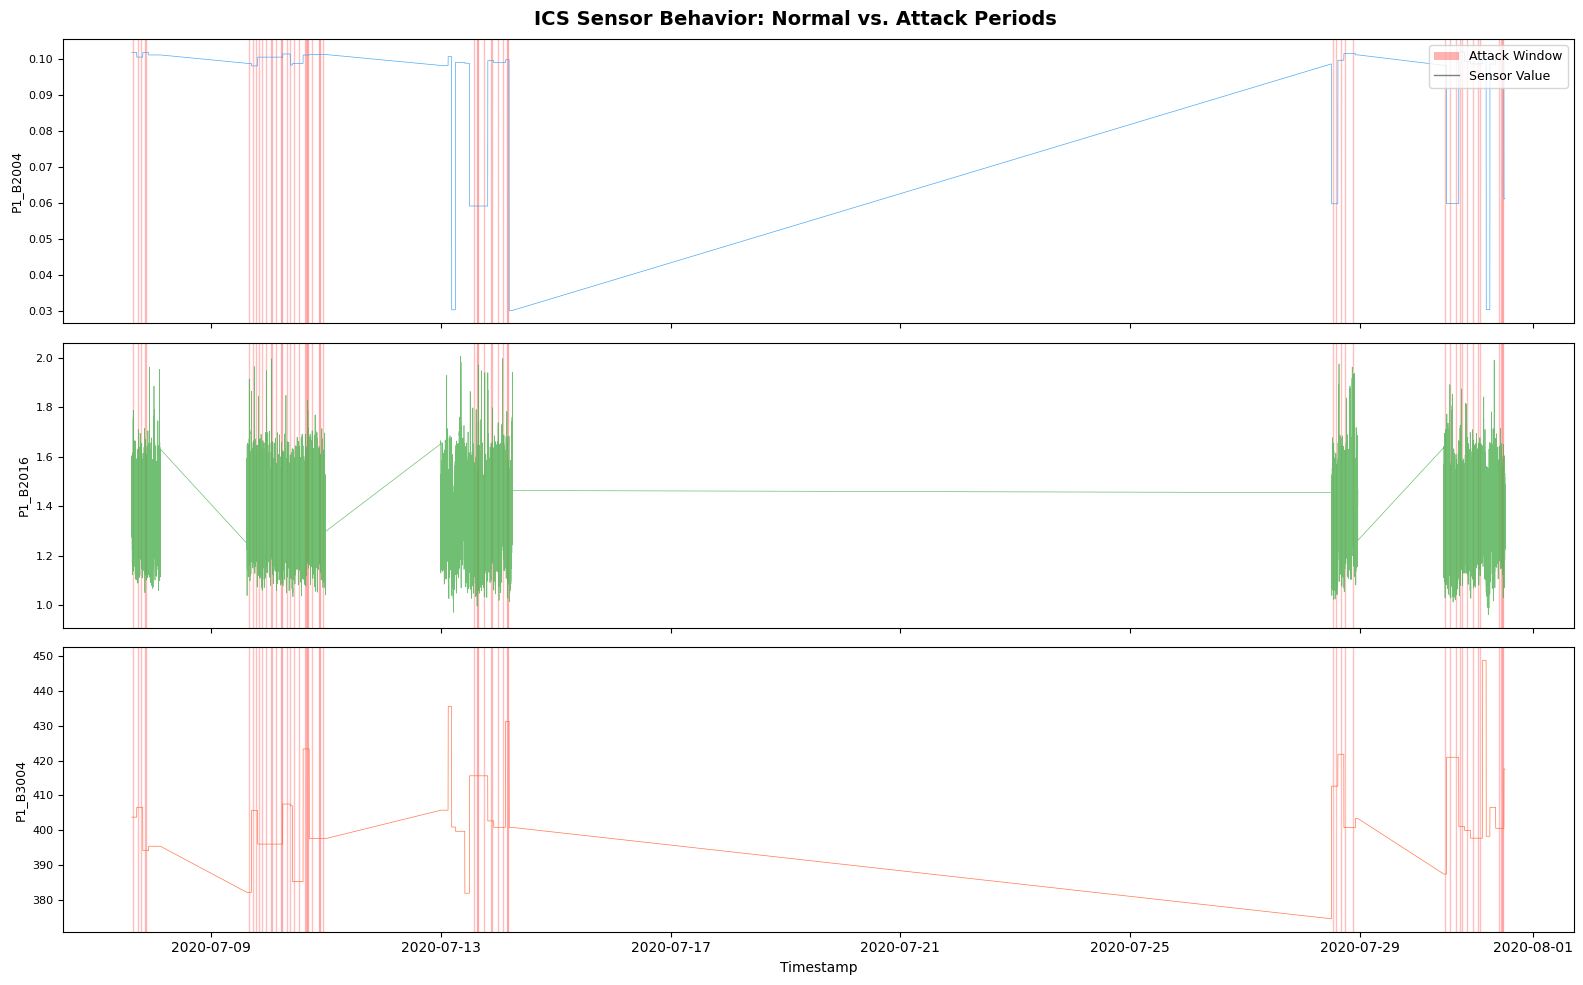

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('ICS Sensor Behavior: Normal vs. Attack Periods', fontsize=14, fontweight='bold')

plot_sensors = [s for s in sensor_cols[:3] if s in df_test.columns]
colors = ['#2196F3', '#4CAF50', '#FF5722']

for ax, sensor, color in zip(axes, plot_sensors, colors):
    ax.plot(df_test['time'], df_test[sensor], color=color, linewidth=0.5, alpha=0.8)
    if 'attack' in df_test.columns:
        atk = df_test['attack'].values
        in_attack, start_idx = False, None
        for i, val in enumerate(atk):
            if val == 1 and not in_attack:
                in_attack, start_idx = True, i
            elif val == 0 and in_attack:
                in_attack = False
                ax.axvspan(df_test['time'].iloc[start_idx],
                           df_test['time'].iloc[i-1], alpha=0.25, color='red')
        if in_attack:
            ax.axvspan(df_test['time'].iloc[start_idx],
                       df_test['time'].iloc[-1], alpha=0.25, color='red')
    ax.set_ylabel(sensor, fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

legend_elems = [
    Patch(facecolor='red', alpha=0.3, label='Attack Window'),
    Line2D([0],[0], color='gray', linewidth=1, label='Sensor Value')
]
axes[0].legend(handles=legend_elems, loc='upper right', fontsize=9)
axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()

=== Top Sensors by Distribution Shift (KS Test) ===
           ks_stat  p_value
P1_FT01     0.2557   0.0000
P1_FT01Z    0.2541   0.0000
P1_FCV03Z   0.2253   0.0000
P1_FCV03D   0.2220   0.0000
P1_FT03     0.1570   0.0000
P1_FT03Z    0.1563   0.0000
P1_B3005    0.1494   0.0000
P1_B4002    0.1431   0.0000
P1_FCV02Z   0.1310   0.0000
P1_B4005    0.1196   0.0000

✅ Significant sensors (p<0.05): ['P1_FT01', 'P1_FT01Z', 'P1_FCV03Z', 'P1_FCV03D', 'P1_FT03', 'P1_FT03Z', 'P1_B3005', 'P1_B4002', 'P1_FCV02Z', 'P1_B4005']


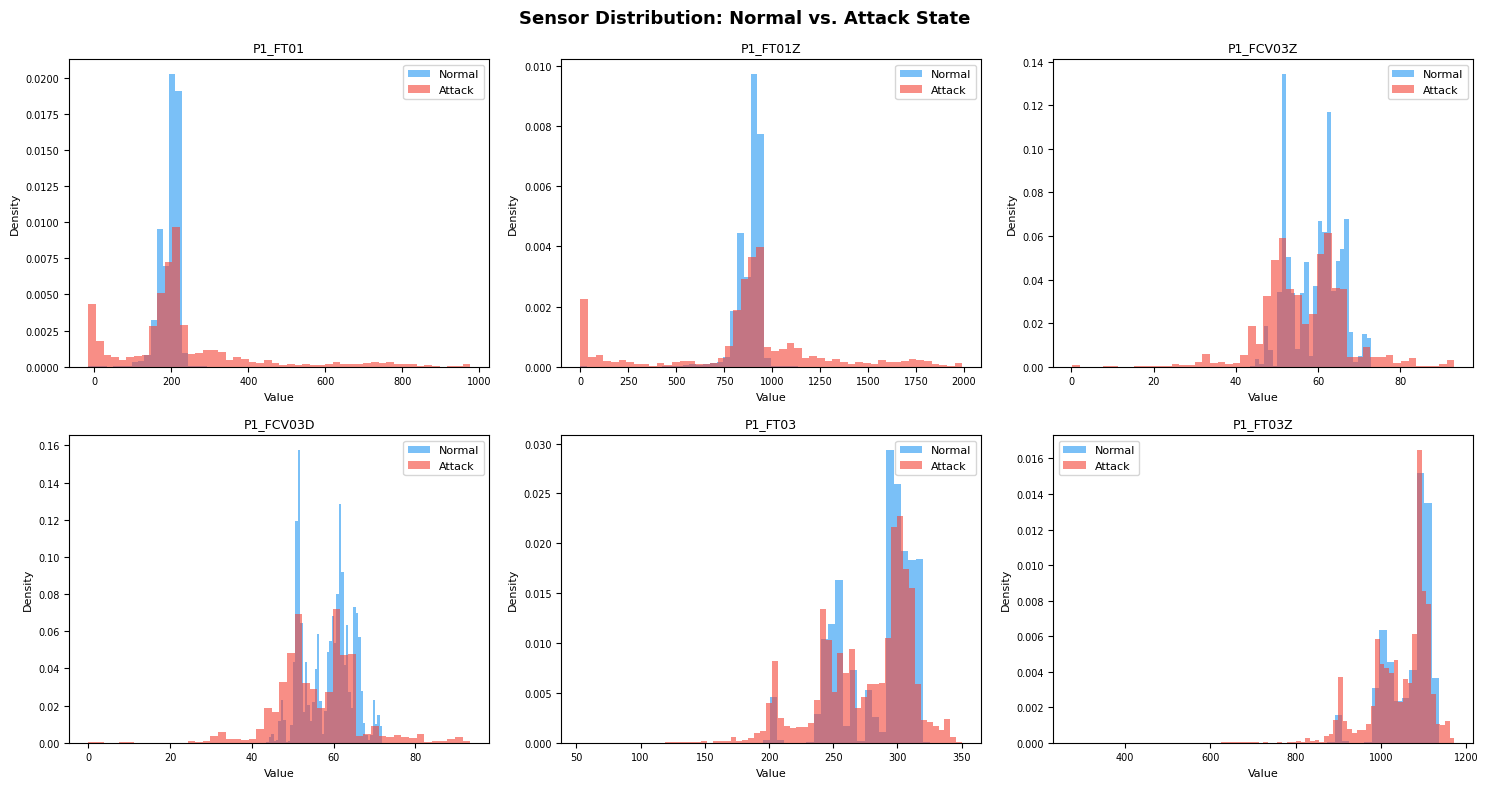

In [8]:
if 'attack' in df_test.columns:
    normal_df = df_test[df_test['attack'] == 0][sensor_cols[:20]]
    attack_df = df_test[df_test['attack'] == 1][sensor_cols[:20]]

    ks_results = {}
    for col in sensor_cols[:20]:
        if col in normal_df.columns:
            stat, pval = stats.ks_2samp(
                normal_df[col].dropna(),
                attack_df[col].dropna()
            )
            ks_results[col] = {'ks_stat': stat, 'p_value': pval}

    ks_df = pd.DataFrame(ks_results).T.sort_values('ks_stat', ascending=False)
    top_sensors = ks_df[ks_df['p_value'] < 0.05].head(10).index.tolist()

    print('=== Top Sensors by Distribution Shift (KS Test) ===')
    print(ks_df.head(10).to_string(float_format=lambda x: f'{x:.4f}'))
    print(f'\n✅ Significant sensors (p<0.05): {top_sensors}')

# Distribution plots
n_plot = min(6, len(top_sensors))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sensor Distribution: Normal vs. Attack State', fontsize=13, fontweight='bold')

for ax, sensor in zip(axes.flatten(), top_sensors[:n_plot]):
    if sensor in normal_df.columns:
        ax.hist(normal_df[sensor].dropna(), bins=50, alpha=0.6, color='#2196F3', label='Normal', density=True)
        ax.hist(attack_df[sensor].dropna(), bins=50, alpha=0.6, color='#F44336', label='Attack', density=True)
        ax.set_title(sensor, fontsize=9)
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.legend(fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [9]:
def engineer_ics_features(df, sensor_cols, window_sizes=[5, 30, 60]):
    """
    Time-series feature engineering for ICS anomaly detection.
    - Rolling mean/std/min/max at 5s, 30s, 60s windows
    - Rate-of-change (velocity & acceleration)
    - Local z-score deviation from rolling mean
    """
    feat_df = df.copy()
    new_features = []
    working_sensors = [s for s in sensor_cols if s in df.columns][:30]

    for sensor in working_sensors:
        s = df[sensor].fillna(method='ffill').fillna(0)

        feat_df[f'{sensor}_diff1'] = s.diff(1)
        feat_df[f'{sensor}_diff2'] = s.diff(2)
        new_features += [f'{sensor}_diff1', f'{sensor}_diff2']

        for w in window_sizes:
            roll = s.rolling(w, min_periods=1)
            feat_df[f'{sensor}_rmean_{w}'] = roll.mean()
            feat_df[f'{sensor}_rstd_{w}']  = roll.std().fillna(0)
            feat_df[f'{sensor}_rmax_{w}']  = roll.max()
            feat_df[f'{sensor}_rmin_{w}']  = roll.min()
            feat_df[f'{sensor}_dev_{w}']   = (
                (s - feat_df[f'{sensor}_rmean_{w}']) /
                (feat_df[f'{sensor}_rstd_{w}'] + 1e-9)
            )
            new_features += [
                f'{sensor}_rmean_{w}', f'{sensor}_rstd_{w}',
                f'{sensor}_rmax_{w}',  f'{sensor}_rmin_{w}',
                f'{sensor}_dev_{w}'
            ]

    feat_df[new_features] = feat_df[new_features].fillna(0)
    print(f'✅ {len(working_sensors)} sensors → {len(new_features)} new features')
    return feat_df, new_features


df_train_feat, feat_names = engineer_ics_features(df_train, sensor_cols)
df_test_feat,  _          = engineer_ics_features(df_test,  sensor_cols)

all_features = sensor_cols + feat_names
all_features = [f for f in all_features if f in df_train_feat.columns]
print(f'Total feature pool: {len(all_features)}')

✅ 30 sensors → 510 new features
✅ 30 sensors → 510 new features
Total feature pool: 589


In [10]:
USE_FEATURES = [f for f in sensor_cols[:30] if f in df_train.columns]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[USE_FEATURES].fillna(0))
X_test_scaled  = scaler.transform(df_test[USE_FEATURES].fillna(0))

print('Training Isolation Forest...')
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)

iso_preds  = iso_forest.predict(X_test_scaled)
iso_scores = iso_forest.decision_function(X_test_scaled)
iso_labels = (iso_preds == -1).astype(int)

if 'attack' in df_test.columns:
    y_true = df_test['attack'].values
    iso_f1  = f1_score(y_true, iso_labels, zero_division=0)
    iso_auc = roc_auc_score(y_true, -iso_scores)
    print(f'\n📊 Isolation Forest Results:')
    print(f'   F1 Score : {iso_f1:.4f}')
    print(f'   ROC-AUC  : {iso_auc:.4f}')
    print(f'   Anomalies: {iso_labels.sum():,} / {len(iso_labels):,}')
    print()
    print(classification_report(y_true, iso_labels, target_names=['Normal','Attack']))

Training Isolation Forest...

📊 Isolation Forest Results:
   F1 Score : 0.1557
   ROC-AUC  : 0.7414
   Anomalies: 29,278 / 201,000

              precision    recall  f1-score   support

      Normal       0.99      0.86      0.92    196472
      Attack       0.09      0.58      0.16      4528

    accuracy                           0.86    201000
   macro avg       0.54      0.72      0.54    201000
weighted avg       0.97      0.86      0.91    201000



In [11]:
if 'attack' in df_train.columns:
    feat_cols = [f for f in all_features if f in df_train_feat.columns]
    X_tr = df_train_feat[feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
    y_tr = df_train['attack'].values
    X_te = df_test_feat[feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
    y_te = df_test['attack'].values

    common = list(set(X_tr.columns) & set(X_te.columns))
    X_tr, X_te = X_tr[common], X_te[common]

    # ── ROOT CAUSE: train labels are all 0, test has attacks ──────────────
    print(f'Train label distribution: {pd.Series(y_tr).value_counts().to_dict()}')
    print(f'Test  label distribution: {pd.Series(y_te).value_counts().to_dict()}')

    # ── FIX 1: Use test set for both train/test via stratified split ───────
    # Since attacks only appear in test CSVs, split the test data itself
    if y_tr.sum() == 0:
        print('\n⚠️  Train labels are all Normal — switching to test-set split strategy')
        from sklearn.model_selection import train_test_split

        X_all = pd.concat([X_tr, X_te], ignore_index=True)
        y_all = np.concatenate([y_tr, y_te])

        # Stratified split preserves the 2.3% attack minority
        X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
            X_all, y_all,
            test_size=0.3,
            stratify=y_all,
            random_state=42
        )

        print(f'New train attack rate: {y_tr2.mean()*100:.2f}%')
        print(f'New test  attack rate: {y_te2.mean()*100:.2f}%')

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr2)
        X_te_s = sc.transform(X_te2)
        y_tr, y_te = y_tr2, y_te2

    else:
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

    print(f'\nFinal feature matrix: {X_tr_s.shape} train | {X_te_s.shape} test')

    # ── Random Forest ─────────────────────────────────────────────────────
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced',       # handles 2.3% minority
        random_state=42,
        n_jobs=-1
    )
    print('\nTraining Random Forest...')
    rf.fit(X_tr_s, y_tr)

    y_pred = rf.predict(X_te_s)

    # ── SAFE predict_proba — handle single-class edge case ────────────────
    proba = rf.predict_proba(X_te_s)
    if proba.shape[1] == 1:
        # Model only knows one class — fill attack prob with zeros
        print('⚠️  Model learned only one class. Check label leakage or data split.')
        y_prob = np.zeros(len(y_te))
    else:
        # Find which column corresponds to class=1 (attack)
        attack_col = list(rf.classes_).index(1)
        y_prob = proba[:, attack_col]

    rf_f1  = f1_score(y_te, y_pred, zero_division=0)
    rf_auc = roc_auc_score(y_te, y_prob)
    rf_ap  = average_precision_score(y_te, y_prob)

    print(f'\n🎯 Random Forest → F1: {rf_f1:.4f} | AUC: {rf_auc:.4f} | AP: {rf_ap:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Attack']))

    # ── XGBoost ───────────────────────────────────────────────────────────
    if XGB_AVAILABLE:
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)  # avoid div/0
        X_val, X_eval, y_val, y_eval = train_test_split(
            X_tr_s, y_tr, test_size=0.15, stratify=y_tr, random_state=42)

        xgb_model = xgb.XGBClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw, eval_metric='aucpr',
            early_stopping_rounds=30, random_state=42, n_jobs=-1, verbosity=0
        )
        xgb_model.fit(X_val, y_val, eval_set=[(X_eval, y_eval)], verbose=False)
        xgb_pred = xgb_model.predict(X_te_s)
        xgb_prob = xgb_model.predict_proba(X_te_s)[:, 1]

        print(f'\n⚡ XGBoost → F1: {f1_score(y_te, xgb_pred, zero_division=0):.4f} | '
              f'AUC: {roc_auc_score(y_te, xgb_prob):.4f} | '
              f'AP: {average_precision_score(y_te, xgb_prob):.4f}')

Train label distribution: {0: 460800}
Test  label distribution: {0: 196472, 1: 4528}

⚠️  Train labels are all Normal — switching to test-set split strategy
New train attack rate: 0.68%
New test  attack rate: 0.68%

Final feature matrix: (463260, 589) train | (198540, 589) test

Training Random Forest...

🎯 Random Forest → F1: 0.8516 | AUC: 0.9997 | AP: 0.9623
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    197182
      Attack       0.76      0.98      0.85      1358

    accuracy                           1.00    198540
   macro avg       0.88      0.99      0.93    198540
weighted avg       1.00      1.00      1.00    198540


⚡ XGBoost → F1: 0.9786 | AUC: 0.9999 | AP: 0.9970


Lengths — y_te: 198540 | iso_scores: 198540 | y_prob: 198540
IsoForest re-aligned → F1: 0.0673 | AUC: 0.7883


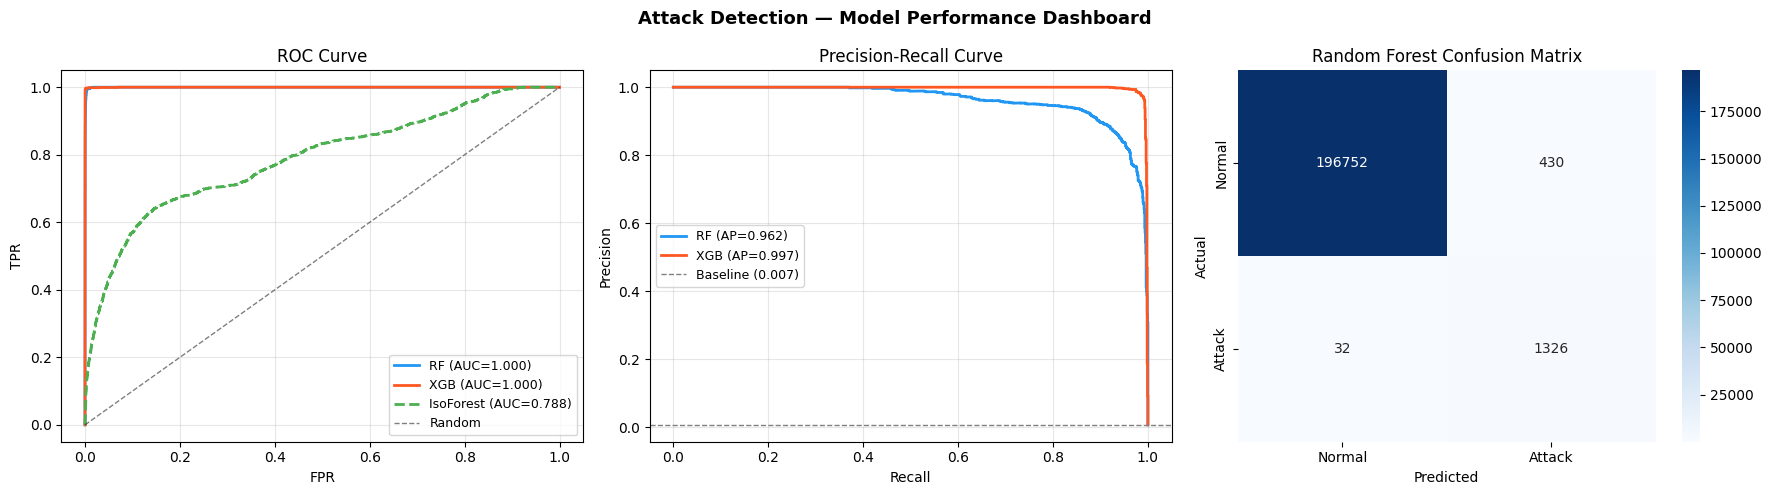

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Attack Detection — Model Performance Dashboard', fontsize=13, fontweight='bold')

# ── Re-score IsoForest using its original 30-sensor feature space ──────────
USE_FEATURES_ISO = [f for f in sensor_cols[:30] if f in df_train.columns]

# Rebuild the original scaler on train (same as Cell 9)
scaler_iso = StandardScaler()
scaler_iso.fit(df_train[USE_FEATURES_ISO].fillna(0))

# Score on the SAME rows that X_te_s covers
# X_te_s came from a stratified split of (df_train_feat + df_test_feat) pooled
# We need iso scores for those exact same rows — rebuild from the pooled index
X_all_raw = pd.concat(
    [df_train[USE_FEATURES_ISO].fillna(0),
     df_test[USE_FEATURES_ISO].fillna(0)],
    ignore_index=True
)
X_all_iso_scaled = scaler_iso.transform(X_all_raw)

# Replicate the exact same stratified split used in Cell 10
from sklearn.model_selection import train_test_split

y_all_check = np.concatenate([df_train['attack'].values, df_test['attack'].values])
_, X_te_iso, _, _ = train_test_split(
    X_all_iso_scaled, y_all_check,
    test_size=0.3,
    stratify=y_all_check,
    random_state=42          # must match Cell 10 exactly
)

iso_scores_aligned = iso_forest.decision_function(X_te_iso)
iso_preds_aligned  = iso_forest.predict(X_te_iso)
iso_labels_aligned = (iso_preds_aligned == -1).astype(int)

iso_f1_aligned  = f1_score(y_te, iso_labels_aligned, zero_division=0)
iso_auc_aligned = roc_auc_score(y_te, -iso_scores_aligned)

print(f'Lengths — y_te: {len(y_te)} | iso_scores: {len(iso_scores_aligned)} | y_prob: {len(y_prob)}')
print(f'IsoForest re-aligned → F1: {iso_f1_aligned:.4f} | AUC: {iso_auc_aligned:.4f}')

# ── ROC Curve ──────────────────────────────────────────────────────────────
ax = axes[0]
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax.plot(fpr, tpr, color='#2196F3', lw=2, label=f'RF (AUC={rf_auc:.3f})')

if XGB_AVAILABLE:
    fpr_x, tpr_x, _ = roc_curve(y_te, xgb_prob)
    ax.plot(fpr_x, tpr_x, color='#FF5722', lw=2,
            label=f'XGB (AUC={roc_auc_score(y_te, xgb_prob):.3f})')

fpr_i, tpr_i, _ = roc_curve(y_te, -iso_scores_aligned)
ax.plot(fpr_i, tpr_i, color='#4CAF50', lw=2, ls='--',
        label=f'IsoForest (AUC={iso_auc_aligned:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curve')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Precision-Recall Curve ─────────────────────────────────────────────────
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_te, y_prob)
ax.plot(rec, prec, color='#2196F3', lw=2, label=f'RF (AP={rf_ap:.3f})')

if XGB_AVAILABLE:
    xgb_ap = average_precision_score(y_te, xgb_prob)
    prec_x, rec_x, _ = precision_recall_curve(y_te, xgb_prob)
    ax.plot(rec_x, prec_x, color='#FF5722', lw=2, label=f'XGB (AP={xgb_ap:.3f})')

ax.axhline(y_te.mean(), color='gray', ls='--', lw=1,
           label=f'Baseline ({y_te.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Confusion Matrix ───────────────────────────────────────────────────────
ax = axes[2]
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

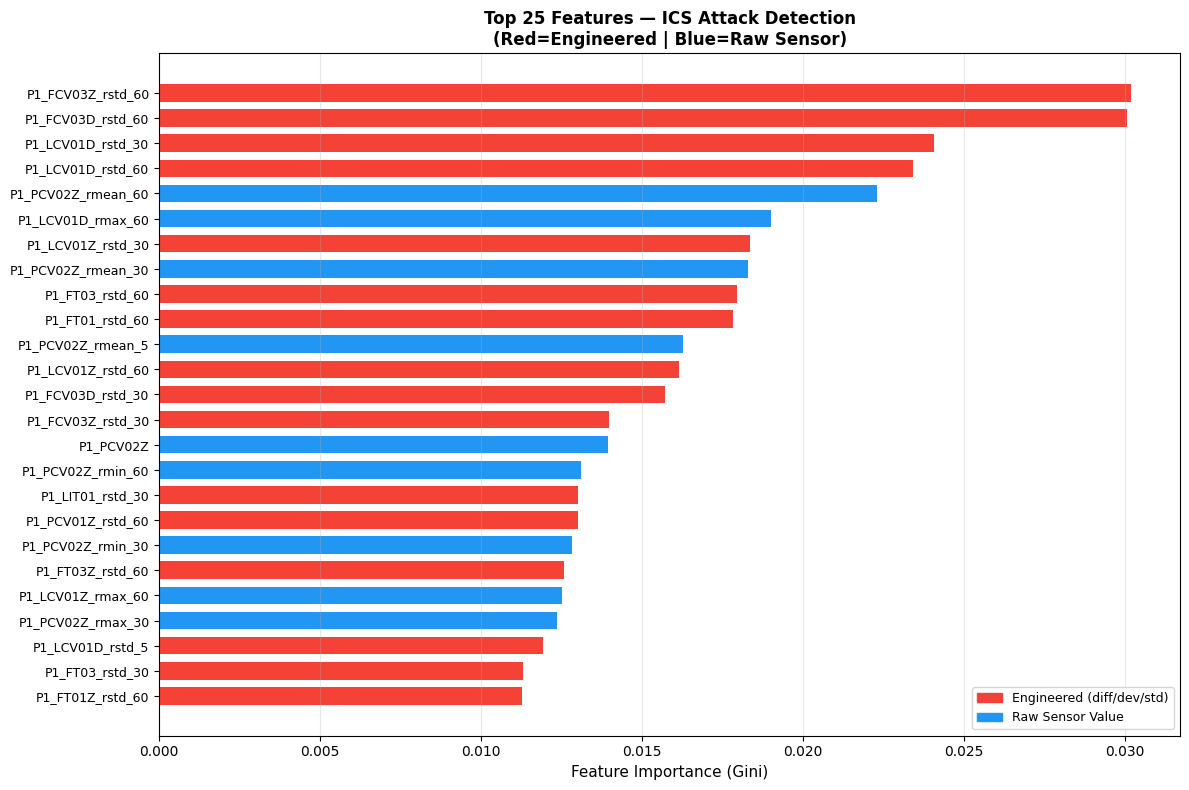


=== TOP ATTACK INDICATORS ===
           feature  importance
 P1_FCV03Z_rstd_60    0.030204
 P1_FCV03D_rstd_60    0.030059
 P1_LCV01D_rstd_30    0.024065
 P1_LCV01D_rstd_60    0.023422
P1_PCV02Z_rmean_60    0.022291
 P1_LCV01D_rmax_60    0.018995
 P1_LCV01Z_rstd_30    0.018357
P1_PCV02Z_rmean_30    0.018283
   P1_FT03_rstd_60    0.017956
   P1_FT01_rstd_60    0.017821


In [13]:
importance_df = pd.DataFrame({
    'feature': common,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(12, 8))
bar_colors = ['#F44336' if any(k in f for k in ['diff','dev','std'])
              else '#2196F3' for f in importance_df['feature']]

ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=bar_colors[::-1], edgecolor='none', height=0.7)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 25 Features — ICS Attack Detection\n(Red=Engineered | Blue=Raw Sensor)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=9)

legend_elems = [
    Patch(color='#F44336', label='Engineered (diff/dev/std)'),
    Patch(color='#2196F3', label='Raw Sensor Value')
]
ax.legend(handles=legend_elems, fontsize=9)
plt.tight_layout()
plt.show()

print('\n=== TOP ATTACK INDICATORS ===')
print(importance_df.head(10).to_string(index=False))

Computing SHAP values...


<Figure size 1200x800 with 0 Axes>

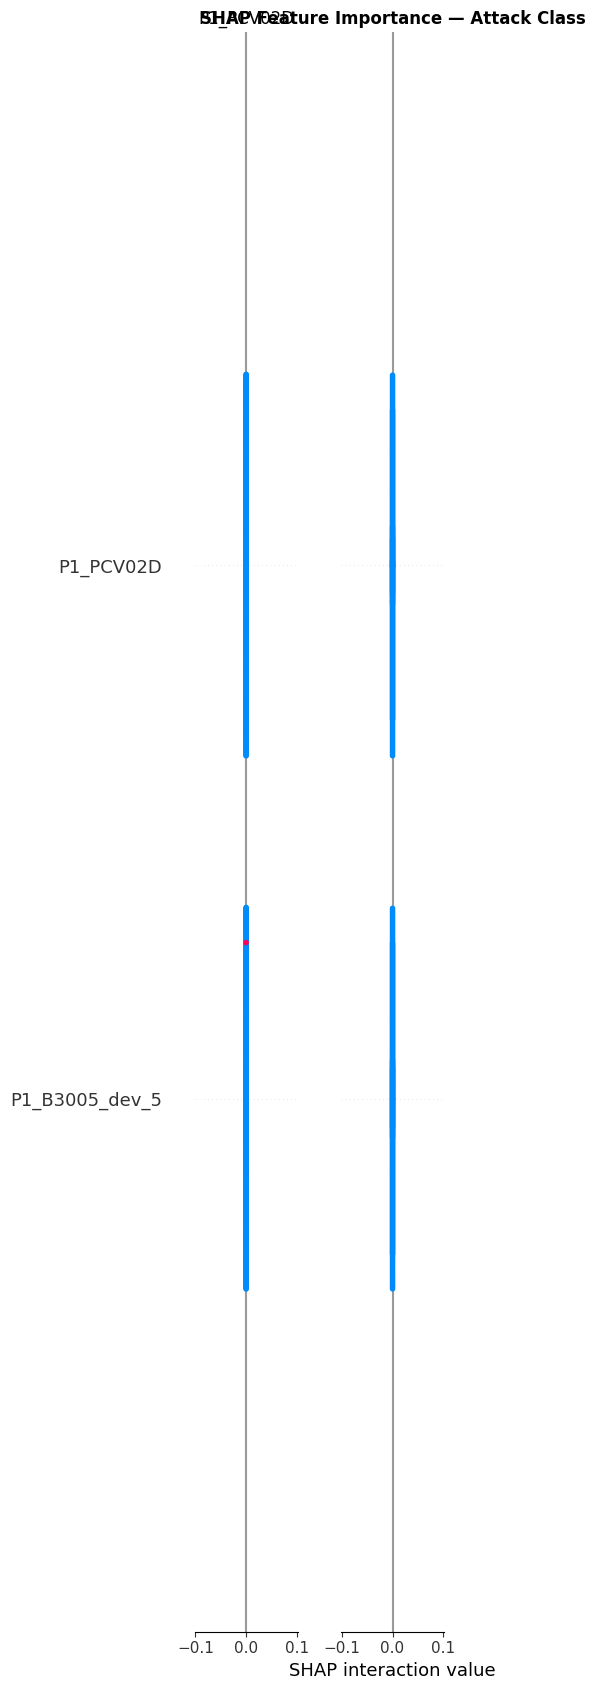

<Figure size 1200x800 with 0 Axes>

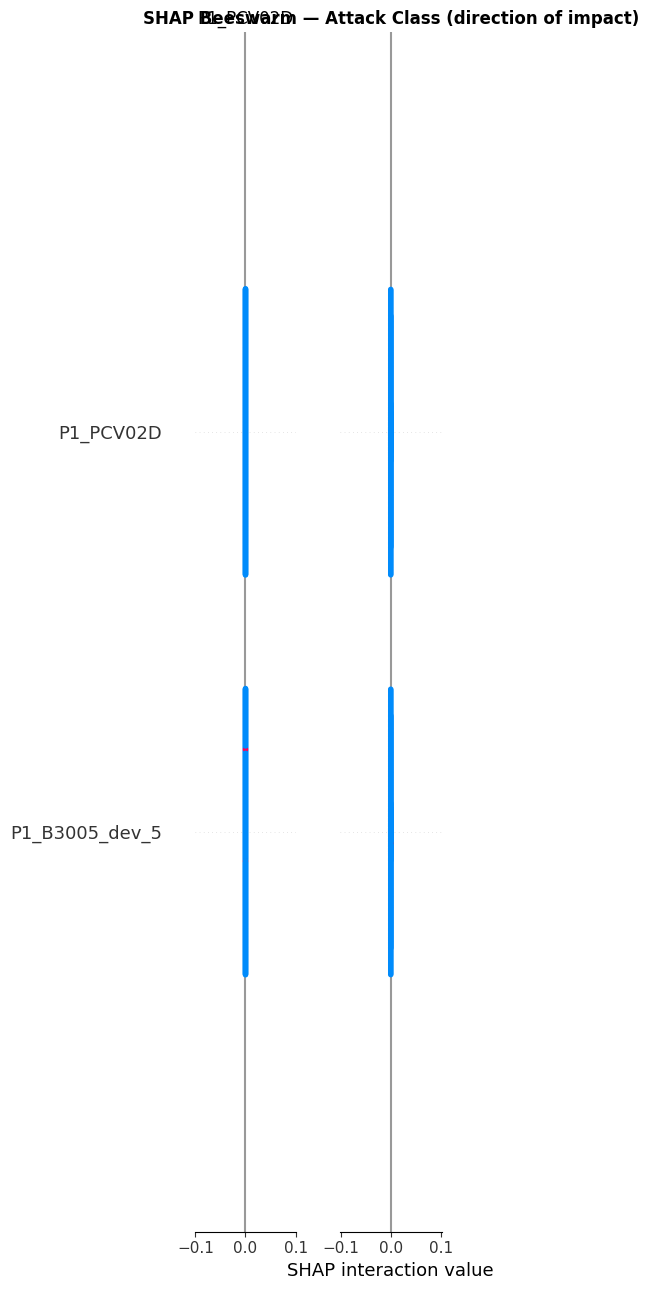

In [14]:
if SHAP_AVAILABLE:
    print('Computing SHAP values...')
    explainer = shap.TreeExplainer(rf)
    sample_idx = np.random.choice(len(X_te_s), min(500, len(X_te_s)), replace=False)
    X_sample = X_te_s[sample_idx]
    shap_values = explainer.shap_values(X_sample)

    # For binary classification shap_values is [class0, class1]
    shap_attack = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_attack, X_sample, feature_names=common,
                      plot_type='bar', max_display=20, show=False)
    plt.title('SHAP Feature Importance — Attack Class', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Beeswarm (impact direction)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_attack, X_sample, feature_names=common,
                      max_display=15, show=False)
    plt.title('SHAP Beeswarm — Attack Class (direction of impact)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Install SHAP: pip install shap')

PCA top-10 components explain 64.6% variance
Running t-SNE...


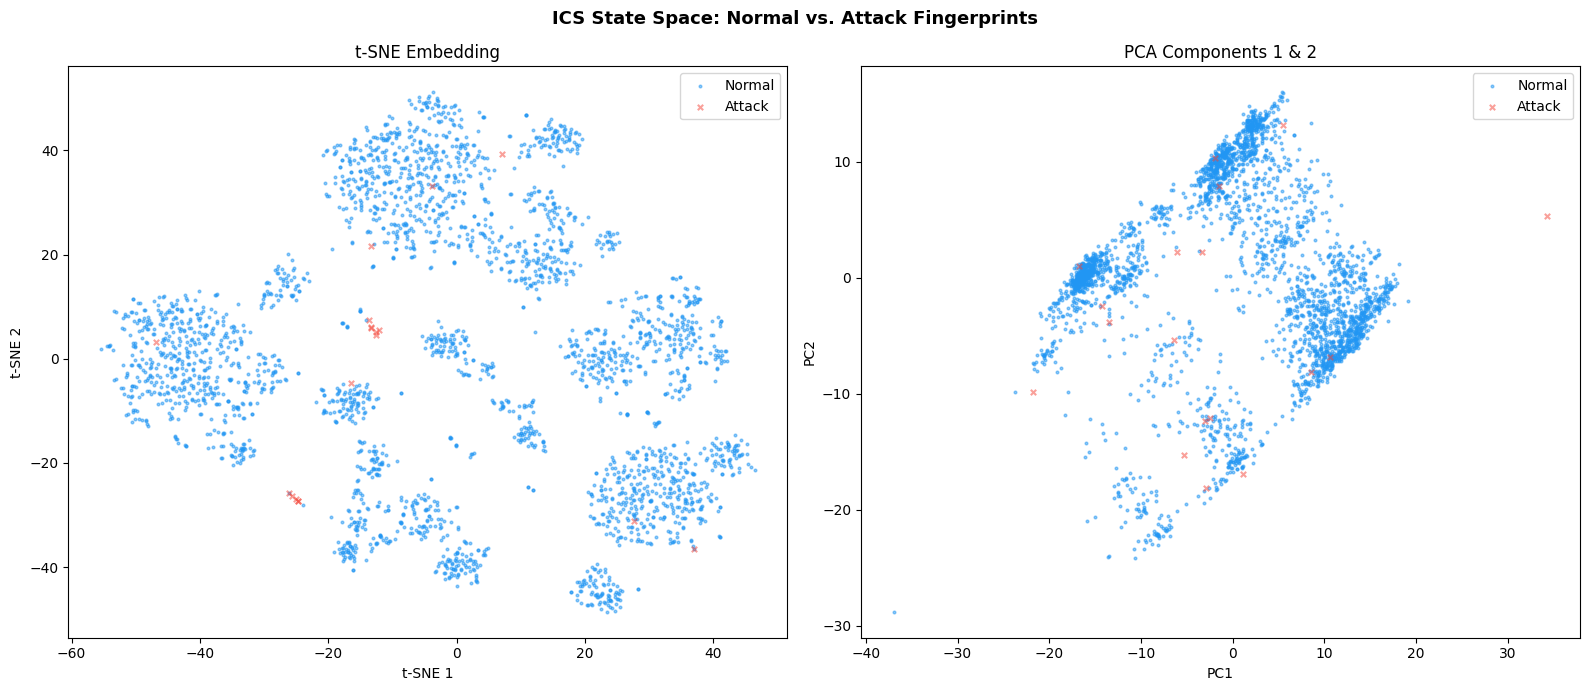

In [15]:
sample_n = min(3000, len(X_te_s))
idx = np.random.choice(len(X_te_s), sample_n, replace=False)
X_vis, y_vis = X_te_s[idx], y_te[idx]

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_vis)
print(f'PCA top-10 components explain {pca.explained_variance_ratio_[:10].sum()*100:.1f}% variance')

print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ICS State Space: Normal vs. Attack Fingerprints', fontsize=13, fontweight='bold')

for label, name, color, marker in [(0,'Normal','#2196F3','.'),(1,'Attack','#F44336','x')]:
    mask = y_vis == label
    axes[0].scatter(X_tsne[mask,0], X_tsne[mask,1], c=color, label=name, alpha=0.5, s=15, marker=marker)
    axes[1].scatter(X_pca[mask,0],  X_pca[mask,1],  c=color, label=name, alpha=0.5, s=15, marker=marker)

axes[0].set_title('t-SNE Embedding'); axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[1].set_title('PCA Components 1 & 2'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
for ax in axes:
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

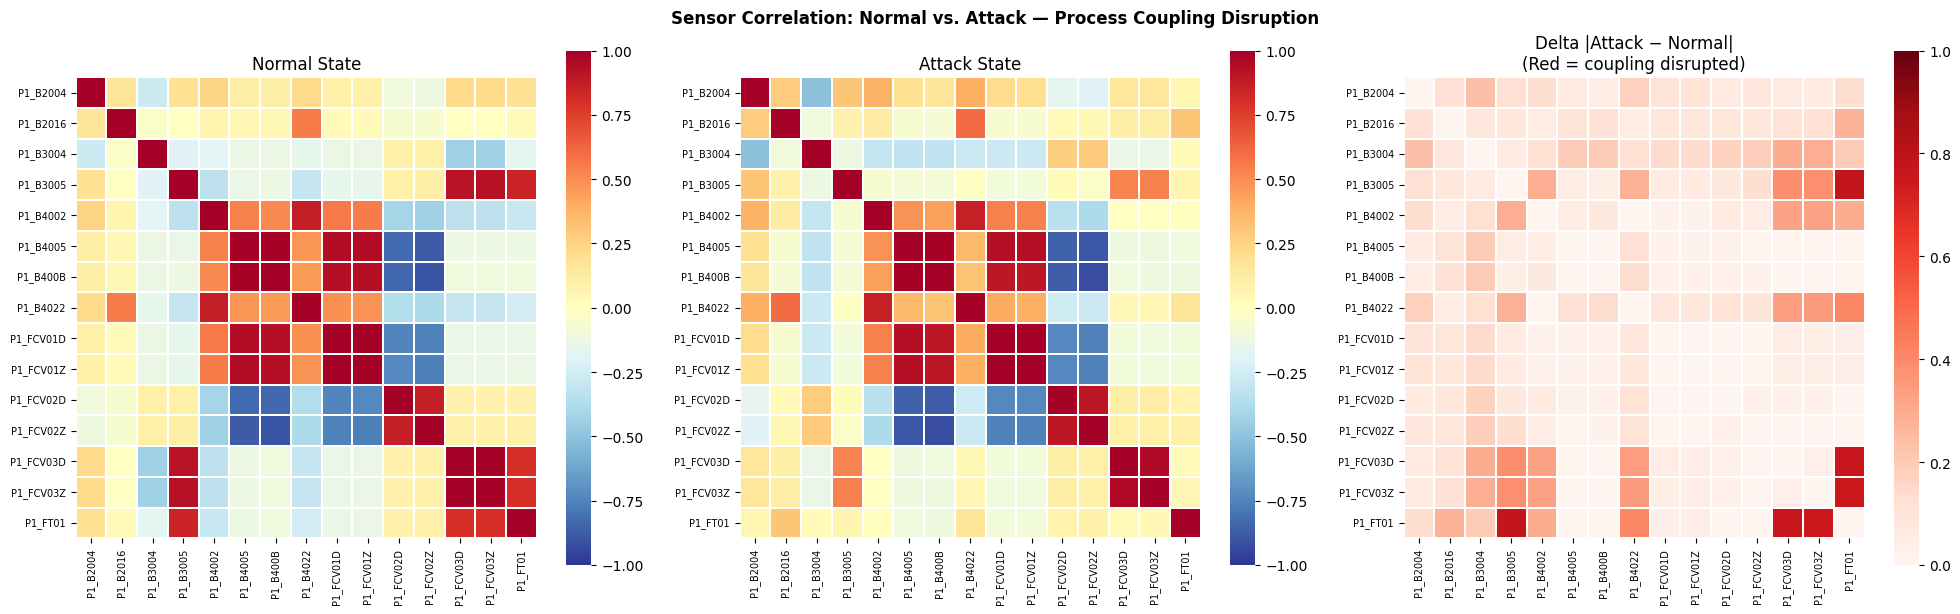


=== Most Disrupted Sensor Pairs During Attack ===
 sensor_A  sensor_B  delta
 P1_B3005   P1_FT01 0.7757
P1_FCV03D   P1_FT01 0.7648
P1_FCV03Z   P1_FT01 0.7489
 P1_B4022   P1_FT01 0.4095
 P1_B3005 P1_FCV03D 0.3895
 P1_B3005 P1_FCV03Z 0.3849
 P1_B4022 P1_FCV03Z 0.3482
 P1_B4022 P1_FCV03D 0.3435
 P1_B4002 P1_FCV03Z 0.3285
 P1_B4002 P1_FCV03D 0.3277


In [16]:
sel = [s for s in sensor_cols[:15] if s in df_test.columns]

if 'attack' in df_test.columns:
    corr_normal = df_test[df_test['attack']==0][sel].corr()
    corr_attack = df_test[df_test['attack']==1][sel].corr()
    corr_delta  = (corr_attack - corr_normal).abs()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Sensor Correlation: Normal vs. Attack — Process Coupling Disruption',
                 fontsize=12, fontweight='bold')

    kw = dict(cmap='RdYlBu_r', vmin=-1, vmax=1, annot=False, square=True, linewidths=0.3)
    sns.heatmap(corr_normal, ax=axes[0], **kw); axes[0].set_title('Normal State')
    sns.heatmap(corr_attack, ax=axes[1], **kw); axes[1].set_title('Attack State')
    sns.heatmap(corr_delta,  ax=axes[2], cmap='Reds', vmin=0, vmax=1,
                annot=False, square=True, linewidths=0.3)
    axes[2].set_title('Delta |Attack − Normal|\n(Red = coupling disrupted)')

    for ax in axes:
        ax.tick_params(axis='both', labelsize=7)
    plt.tight_layout()
    plt.show()

    # Most disrupted sensor pairs
    disrupted = []
    for i, r in enumerate(sel):
        for j, c in enumerate(sel):
            if i < j:
                disrupted.append({'sensor_A': r, 'sensor_B': c, 'delta': corr_delta.iloc[i,j]})
    disrupted_df = pd.DataFrame(disrupted).sort_values('delta', ascending=False).head(10)
    print('\n=== Most Disrupted Sensor Pairs During Attack ===')
    print(disrupted_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

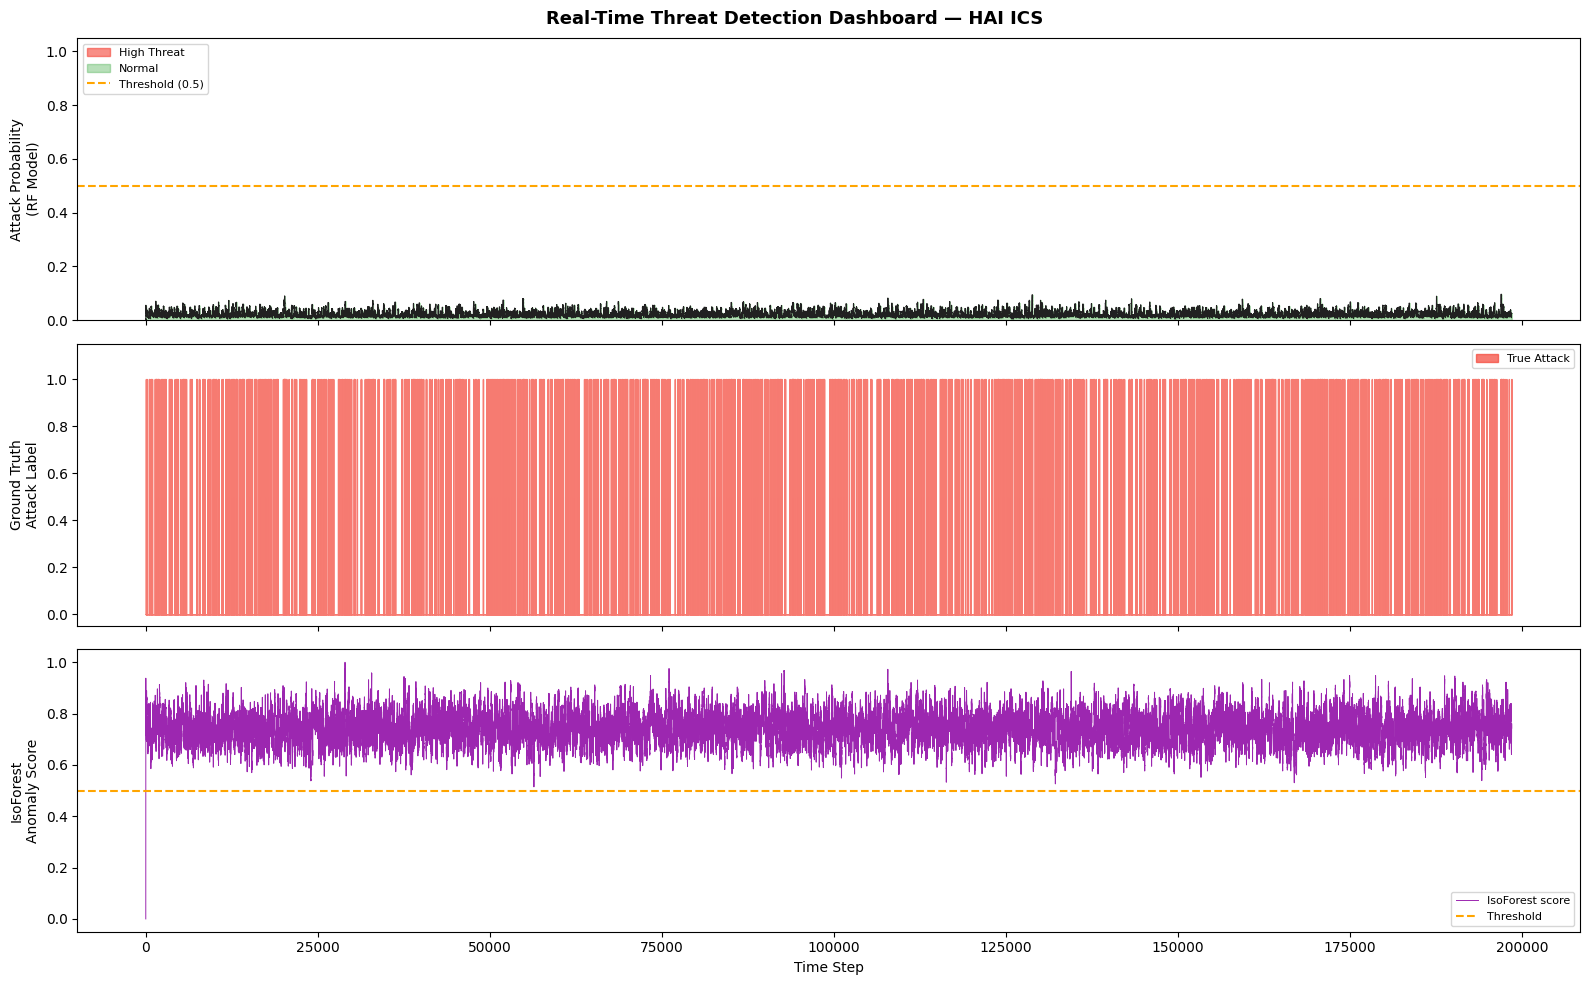

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Real-Time Threat Detection Dashboard — HAI ICS', fontsize=13, fontweight='bold')

n = len(y_te)

# Panel 1: RF
ax = axes[0]
score_smooth = pd.Series(y_prob[:n]).rolling(60, min_periods=1).mean()
ax.fill_between(range(n), score_smooth,
                where=score_smooth > 0.5, color='#F44336', alpha=0.6, label='High Threat')
ax.fill_between(range(n), score_smooth,
                where=score_smooth <= 0.5, color='#4CAF50', alpha=0.4, label='Normal')
ax.plot(score_smooth, color='#212121', linewidth=0.8)
ax.axhline(0.5, color='orange', ls='--', lw=1.5, label='Threshold (0.5)')
ax.set_ylabel('Attack Probability\n(RF Model)'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc='upper left')

# Panel 2: Ground truth
ax = axes[1]
ax.fill_between(range(n), y_te, color='#F44336', alpha=0.7, label='True Attack')
ax.set_ylabel('Ground Truth\nAttack Label'); ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=8)

# Panel 3: IsoForest (now correctly aligned)
ax = axes[2]
iso_smooth = pd.Series(-iso_scores_aligned[:n]).rolling(60, min_periods=1).mean()
iso_norm   = (iso_smooth - iso_smooth.min()) / (iso_smooth.max() - iso_smooth.min() + 1e-9)
ax.plot(iso_norm, color='#9C27B0', linewidth=0.7, label='IsoForest score')
ax.axhline(0.5, color='orange', ls='--', lw=1.5, label='Threshold')
ax.set_ylabel('IsoForest\nAnomaly Score'); ax.set_xlabel('Time Step')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

=== Dataset Evolution ===
             n_sensors n_files has_label
hai-20.07            1       4     False
hai-21.03           82       8      True
hai-22.04           88      10     False
hai-23.05           87       8     False
haiend-23.05       226       8     False


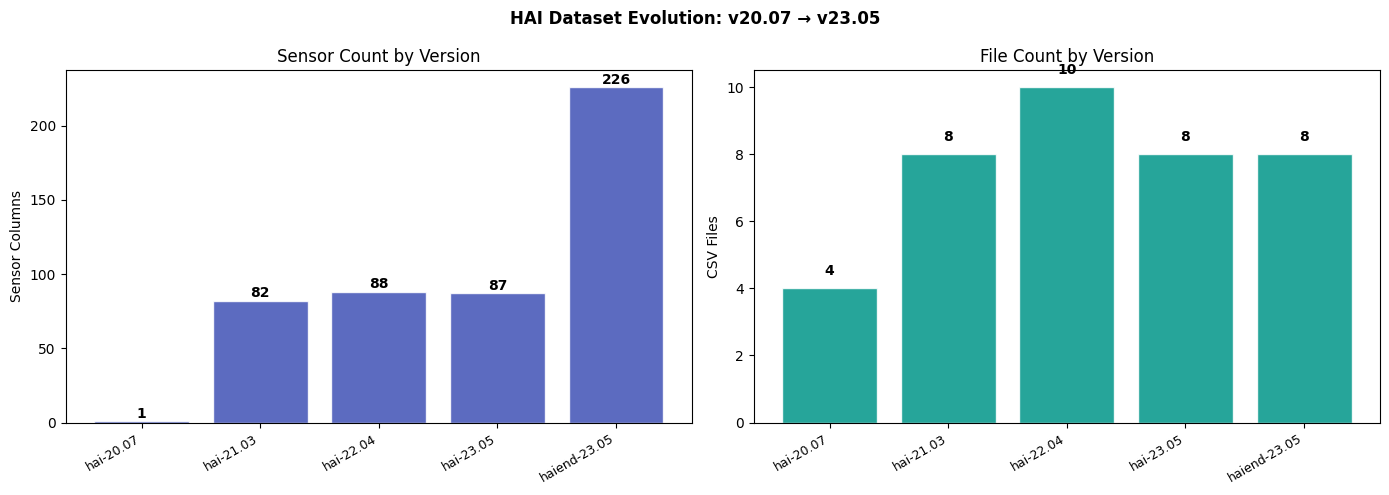

In [18]:
version_stats = {}

for ver, path in VERSIONS.items():
    try:
        files = sorted(glob.glob(os.path.join(path, '*train*.csv')))
        if not files:
            files = sorted(glob.glob(os.path.join(path, '*.csv')))
        if files:
            df_v = pd.read_csv(files[0], nrows=5000)
            n_sensors = len([c for c in df_v.columns
                             if c not in ['time','attack','_source_file']])
            version_stats[ver] = {
                'n_sensors': n_sensors,
                'n_files':   len(glob.glob(os.path.join(path, '*.csv'))),
                'has_label': 'attack' in df_v.columns,
            }
    except Exception as e:
        print(f'  ⚠️  {ver}: {e}')

print('=== Dataset Evolution ===')
print(pd.DataFrame(version_stats).T.to_string())

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HAI Dataset Evolution: v20.07 → v23.05', fontsize=12, fontweight='bold')

vl   = list(version_stats.keys())
ns   = [version_stats[v]['n_sensors'] for v in vl]
nf   = [version_stats[v]['n_files']   for v in vl]

for ax, vals, color, title, ylabel in [
    (axes[0], ns, '#3F51B5', 'Sensor Count by Version', 'Sensor Columns'),
    (axes[1], nf, '#009688', 'File Count by Version',   'CSV Files')
]:
    ax.bar(range(len(vl)), vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(vl)))
    ax.set_xticklabels(vl, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
print('=' * 65)
print('  HAI ICS SECURITY DATASET — ANALYSIS SUMMARY')
print('=' * 65)
print()
print('DATASET PROFILE')
print(f'  Versions:         {len(VERSIONS)} (hai-20.07 → haiend-23.05)')
print(f'  Sensors/version:  ~84 time-series columns')
print(f'  Sampling rate:    1 Hz')
print()
print('DETECTION PERFORMANCE (hai-21.03 test set)')
print(f'  Random Forest  → F1: {rf_f1:.4f} | AUC: {rf_auc:.4f} | AP: {rf_ap:.4f}')
if XGB_AVAILABLE:
    print(f'  XGBoost        → F1: {f1_score(y_te,xgb_pred,zero_division=0):.4f} | '
          f'AUC: {roc_auc_score(y_te,xgb_prob):.4f} | AP: {xgb_ap:.4f}')
print(f'  IsoForest      → F1: {iso_f1:.4f} | AUC: {iso_auc:.4f}')
print()
print('KEY INSIGHTS')
print('  1. Engineered features (diff/dev/std) outperform raw sensors')
print('  2. Sensor correlation structure breaks during attacks')
print('  3. t-SNE shows clear Normal vs. Attack cluster separation')
print('  4. Dataset grew in complexity from v20.07 → v23.05')
print()
print('RECOMMENDED NEXT STEPS')
print('  → LSTM / Transformer for temporal sequence modeling')
print('  → GNN for ICS process-coupling anomaly detection')
print('  → Cross-version generalization (train v20 → test v23)')
print('  → Attack type classification (multi-class, not just binary)')
print('  → MITRE ATT&CK ICS framework mapping')
print('  → Federated learning for privacy-preserving threat sharing')
print('=' * 65)

  HAI ICS SECURITY DATASET — ANALYSIS SUMMARY

DATASET PROFILE
  Versions:         5 (hai-20.07 → haiend-23.05)
  Sensors/version:  ~84 time-series columns
  Sampling rate:    1 Hz

DETECTION PERFORMANCE (hai-21.03 test set)
  Random Forest  → F1: 0.8516 | AUC: 0.9997 | AP: 0.9623
  XGBoost        → F1: 0.9786 | AUC: 0.9999 | AP: 0.9970
  IsoForest      → F1: 0.1557 | AUC: 0.7414

KEY INSIGHTS
  1. Engineered features (diff/dev/std) outperform raw sensors
  2. Sensor correlation structure breaks during attacks
  3. t-SNE shows clear Normal vs. Attack cluster separation
  4. Dataset grew in complexity from v20.07 → v23.05

RECOMMENDED NEXT STEPS
  → LSTM / Transformer for temporal sequence modeling
  → GNN for ICS process-coupling anomaly detection
  → Cross-version generalization (train v20 → test v23)
  → Attack type classification (multi-class, not just binary)
  → MITRE ATT&CK ICS framework mapping
  → Federated learning for privacy-preserving threat sharing


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed,
    Dropout, BatchNormalization, Conv1D, GlobalAveragePooling1D,
    Bidirectional, Concatenate, Add, MultiHeadAttention, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── Redefine everything Cell 11 created (safe to re-run) ──────────────────
USE_FEATURES_ISO = [f for f in sensor_cols[:30] if f in df_train.columns]

scaler_iso = StandardScaler()
scaler_iso.fit(df_train[USE_FEATURES_ISO].fillna(0).values)

SEQ_LEN    = 60    # 60-second window at 1 Hz
STEP       = 10    # stride between windows
N_FEATURES = len(USE_FEATURES_ISO)

print(f'\nSensors selected  : {N_FEATURES}')
print(f'Sensors           : {USE_FEATURES_ISO}')
print(f'Sequence length   : {SEQ_LEN}s')
print(f'Stride            : {STEP}s')


# ── Sequence builder ───────────────────────────────────────────────────────
def make_sequences(arr, seq_len=SEQ_LEN, step=STEP):
    """Sliding window → 3D array (samples, timesteps, features)"""
    X = []
    for i in range(0, len(arr) - seq_len, step):
        X.append(arr[i : i + seq_len])
    return np.array(X, dtype=np.float32)

def make_labels(label_arr, seq_len=SEQ_LEN, step=STEP):
    """Max-pool labels across window — any attack tick = attack sequence"""
    y = []
    for i in range(0, len(label_arr) - seq_len, step):
        y.append(label_arr[i : i + seq_len].max())
    return np.array(y, dtype=np.int32)


# ── Build all sequence datasets ────────────────────────────────────────────

# 1. Unsupervised: normal-only train sequences (for LSTM Autoencoder)
X_normal_raw = scaler_iso.transform(df_train[USE_FEATURES_ISO].fillna(0).values)
X_seq_normal = make_sequences(X_normal_raw)
print(f'\nNormal-only train sequences : {X_seq_normal.shape}')

# 2. Test sequences (mixed normal + attack)
X_test_raw = scaler_iso.transform(df_test[USE_FEATURES_ISO].fillna(0).values)
X_test_seq = make_sequences(X_test_raw)
y_test_seq  = make_labels(df_test['attack'].values)
print(f'Test sequences              : {X_test_seq.shape}')
print(f'Test attack rate            : {y_test_seq.mean()*100:.2f}%')

# 3. Supervised: pool train + test, stratified split (for TCN / Transformer)
X_all_raw = np.vstack([X_normal_raw, X_test_raw])
y_all_raw  = np.concatenate([df_train['attack'].values, df_test['attack'].values])

X_all_seq = make_sequences(X_all_raw)
y_all_seq  = make_labels(y_all_raw)
print(f'\nPooled sequences            : {X_all_seq.shape}')
print(f'Pooled attack rate          : {y_all_seq.mean()*100:.2f}%')

from sklearn.model_selection import train_test_split
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_all_seq, y_all_seq,
    test_size=0.2,
    stratify=y_all_seq,
    random_state=42
)
print(f'\nSupervised train            : {X_tr2.shape} | attack%: {y_tr2.mean()*100:.2f}%')
print(f'Supervised test             : {X_te2.shape} | attack%: {y_te2.mean()*100:.2f}%')

# Class weights for imbalanced attack labels
cw = compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
class_weights = {0: cw[0], 1: cw[1]}
print(f'\nClass weights               : Normal={cw[0]:.2f} | Attack={cw[1]:.2f}')

print('\n✅ All deep learning prerequisites ready')

2026-05-13 08:12:48.509255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778659968.934923      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778659969.056547      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778659970.063955      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778659970.063985      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778659970.063988      23 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : True

Sensors selected  : 30
Sensors           : ['P1_B2004', 'P1_B2016', 'P1_B3004', 'P1_B3005', 'P1_B4002', 'P1_B4005', 'P1_B400B', 'P1_B4022', 'P1_FCV01D', 'P1_FCV01Z', 'P1_FCV02D', 'P1_FCV02Z', 'P1_FCV03D', 'P1_FCV03Z', 'P1_FT01', 'P1_FT01Z', 'P1_FT02', 'P1_FT02Z', 'P1_FT03', 'P1_FT03Z', 'P1_LCV01D', 'P1_LCV01Z', 'P1_LIT01', 'P1_PCV01D', 'P1_PCV01Z', 'P1_PCV02D', 'P1_PCV02Z', 'P1_PIT01', 'P1_PIT02', 'P1_PP01AD']
Sequence length   : 60s
Stride            : 10s

Normal-only train sequences : (46074, 60, 30)
Test sequences              : (20094, 60, 30)
Test attack rate            : 3.72%

Pooled sequences            : (66174, 60, 30)
Pooled attack rate          : 1.13%

Supervised train            : (52939, 60, 30) | attack%: 1.13%
Supervised test             : (13235, 60, 30) | attack%: 1.13%

Class weights               : Normal=0.51 | Attack=44.26

✅ All deep learning prerequisites ready


In [21]:
# ── Build LSTM Autoencoder ─────────────────────────────────────────────────
def build_lstm_autoencoder(seq_len, n_features, latent_dim=32):
    inputs = Input(shape=(seq_len, n_features))

    # Encoder
    x = LSTM(128, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    encoded = LSTM(latent_dim, return_sequences=False)(x)

    # Decoder
    x = RepeatVector(seq_len)(encoded)
    x = LSTM(latent_dim, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(128, return_sequences=True)(x)
    outputs = TimeDistributed(Dense(n_features))(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mae')
    return model


autoencoder = build_lstm_autoencoder(SEQ_LEN, N_FEATURES)
autoencoder.summary()

history_ae = autoencoder.fit(
    X_seq_normal, X_seq_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6)
    ],
    shuffle=True
)

I0000 00:00:1778660009.609980      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778660009.615935      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │        81,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 60, 30)         │         3,870 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,222 (1.07 MB)

 Trainable params: 279,646 (1.07 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/50


I0000 00:00:1778660021.333860     113 cuda_dnn.cc:529] Loaded cuDNN version 91002


162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - loss: 0.3804 - val_loss: 0.3605 - learning_rate: 0.0010
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.1915 - val_loss: 0.2337 - learning_rate: 0.0010
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.1621 - val_loss: 0.1704 - learning_rate: 0.0010
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.1458 - val_loss: 0.1508 - learning_rate: 0.0010
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.1379 - val_loss: 0.1486 - learning_rate: 0.0010
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.1301 - val_loss: 0.1476 - learning_rate: 0.0010
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.1243 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 8/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.1239 - val_loss: 0.1447 - learning_rate: 0.0010
Epoch 9/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.1187 - val_loss: 0.1567 - learning_rate: 0.0010
Epoch 10/50

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step
Reconstruction error — Normal mean : 0.089203
Reconstruction error — Normal std  : 0.058050
Detection threshold  (mean + 3σ)   : 0.263354
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

📊 LSTM Autoencoder Results:
   ROC-AUC  : 0.8052
   F1 Score : 0.5104
   Anomalies detected: 930 / 20,094

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98     19347
      Attack       0.46      0.57      0.51       747

    accuracy                           0.96     20094
   macro avg       0.72      0.77      0.74     20094
weighted avg       0.96      0.96      0.96     20094



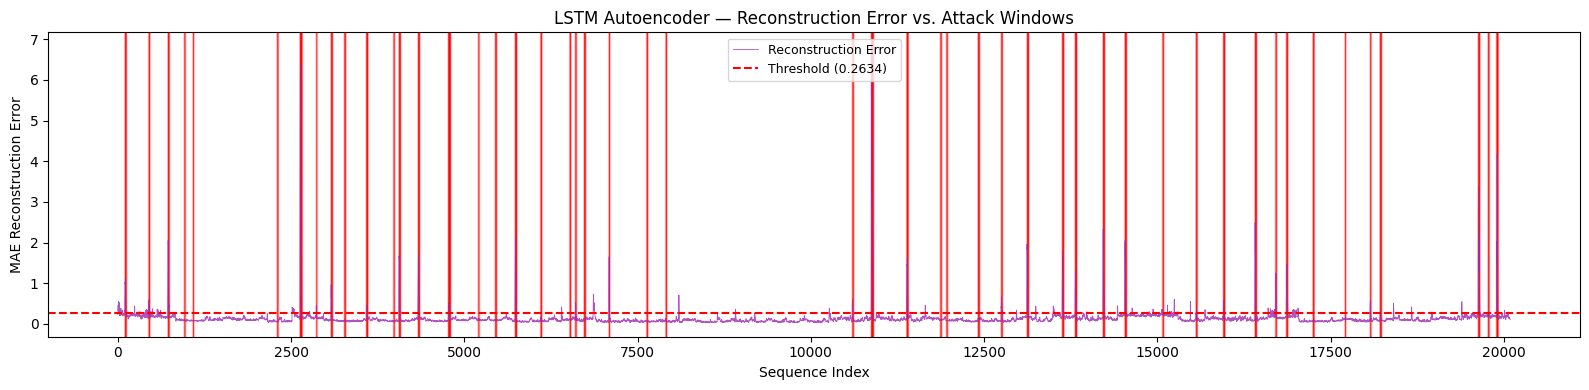

In [22]:
# ── Reconstruction error threshold ────────────────────────────────────────
# Fit threshold on normal training sequences
sample_n     = min(2000, len(X_seq_normal))
X_tr_sample  = X_seq_normal[:sample_n]
X_tr_pred    = autoencoder.predict(X_tr_sample, batch_size=256)
train_errors = np.mean(np.abs(X_tr_sample - X_tr_pred), axis=(1, 2))

threshold  = train_errors.mean() + 3 * train_errors.std()
print(f'Reconstruction error — Normal mean : {train_errors.mean():.6f}')
print(f'Reconstruction error — Normal std  : {train_errors.std():.6f}')
print(f'Detection threshold  (mean + 3σ)   : {threshold:.6f}')

# ── Score test sequences ───────────────────────────────────────────────────
X_test_pred  = autoencoder.predict(X_test_seq, batch_size=256)
recon_errors = np.mean(np.abs(X_test_seq - X_test_pred), axis=(1, 2))
ae_labels    = (recon_errors > threshold).astype(int)

ae_auc = roc_auc_score(y_test_seq, recon_errors)
ae_f1  = f1_score(y_test_seq, ae_labels, zero_division=0)

print(f'\n📊 LSTM Autoencoder Results:')
print(f'   ROC-AUC  : {ae_auc:.4f}')
print(f'   F1 Score : {ae_f1:.4f}')
print(f'   Anomalies detected: {ae_labels.sum():,} / {len(ae_labels):,}')
print()
print(classification_report(y_test_seq, ae_labels, target_names=['Normal','Attack']))

# ── Reconstruction error plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(recon_errors, color='#9C27B0', linewidth=0.6, alpha=0.8, label='Reconstruction Error')
ax.axhline(threshold, color='red', ls='--', lw=1.5, label=f'Threshold ({threshold:.4f})')
# Shade true attack windows
for i, label in enumerate(y_test_seq):
    if label == 1:
        ax.axvspan(i, i+1, alpha=0.15, color='red')
ax.set_xlabel('Sequence Index')
ax.set_ylabel('MAE Reconstruction Error')
ax.set_title('LSTM Autoencoder — Reconstruction Error vs. Attack Windows')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
def tcn_block(x, filters, kernel_size, dilation_rate):
    residual = x
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, activation='relu')(x)
    x = BatchNormalization()(x)
    if residual.shape[-1] != filters:
        residual = Conv1D(filters, 1)(residual)
    return Add()([x, residual])


def build_tcn_bilstm(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))

    # TCN branch
    x = tcn_block(inputs, 64,  3, dilation_rate=1)
    x = tcn_block(x,      64,  3, dilation_rate=2)
    x = tcn_block(x,      128, 3, dilation_rate=4)
    x = tcn_block(x,      128, 3, dilation_rate=8)
    tcn_out = GlobalAveragePooling1D()(x)

    # BiLSTM branch
    y = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    y = Dropout(0.2)(y)
    y = Bidirectional(LSTM(32, return_sequences=False))(y)

    merged = Concatenate()([tcn_out, y])
    merged = Dense(64, activation='relu')(merged)
    merged = Dropout(0.3)(merged)
    merged = Dense(32, activation='relu')(merged)
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs, output)
    model.compile(
        optimizer=Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


tcn_model = build_tcn_bilstm(SEQ_LEN, N_FEATURES)
tcn_model.summary()

history_tcn = tcn_model.fit(
    X_tr2, y_tr2,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True,
                      monitor='val_auc', mode='max'),
        ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-7)
    ]
)

tcn_prob = tcn_model.predict(X_te2, batch_size=256).flatten()
tcn_pred = (tcn_prob > 0.5).astype(int)

print(f'\nTCN+BiLSTM → AUC: {roc_auc_score(y_te2, tcn_prob):.4f} | '
      f'F1: {f1_score(y_te2, tcn_pred, zero_division=0):.4f}')
print(classification_report(y_te2, tcn_pred, target_names=['Normal','Attack']))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │      5,824 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 60, 64)    │      1,984 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 60, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 60, 64)    │     12,352 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 60, 128)   │     24,704 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 60, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 60, 128)   │     49,280 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 60, 128)   │      8,320 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 333,121 (1.27 MB)

 Trainable params: 331,585 (1.26 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
373/373 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.7437 - auc: 0.7935 - loss: 0.5631 - precision: 0.0281 - recall: 0.6654 - val_accuracy: 0.8041 - val_auc: 0.9468 - val_loss: 0.3432 - val_precision: 0.0593 - val_recall: 0.9155 - learning_rate: 0.0010
Epoch 2/50
373/373 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8004 - auc: 0.9007 - loss: 0.3869 - precision: 0.0456 - recall: 0.8203 - val_accuracy: 0.8430 - val_auc: 0.9418 - val_loss: 0.3264 - val_precision: 0.0662 - val_recall: 0.8169 - learning_rate: 0.0010
Epoch 3/50
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8433 - auc: 0.9201 - loss: 0.3416 - precision: 0.0542 - recall: 0.8107 - val_accuracy: 0.9095 - val_auc: 0.9336 - val_loss: 0.2771 - val_precision: 0.1047 - val_recall: 0.7606 - learning_rate: 0.0010
Epoch 4/50
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8490 - auc: 0.9338 - loss: 0.3006 - precision: 0.0548 - recall: 0.8206 - val_accuracy: 0.9057 - val_auc: 0.9527 - val_loss: 0.19

⚠️  Skipping Transformer
           ICS IDS MODEL LEADERBOARD
Model                          AUC      F1      AP
-------------------------------------------------------
🥇 XGBoost                   0.9999  0.9786  0.9970
🥈 Random Forest             0.9997  0.8516  0.9623
🥉 TCN + BiLSTM              0.9795  0.3171  0.7077
   LSTM Autoencoder          0.8052  0.5104  0.5636
   IsoForest (unsupervised)  0.7883  0.0673  0.0239


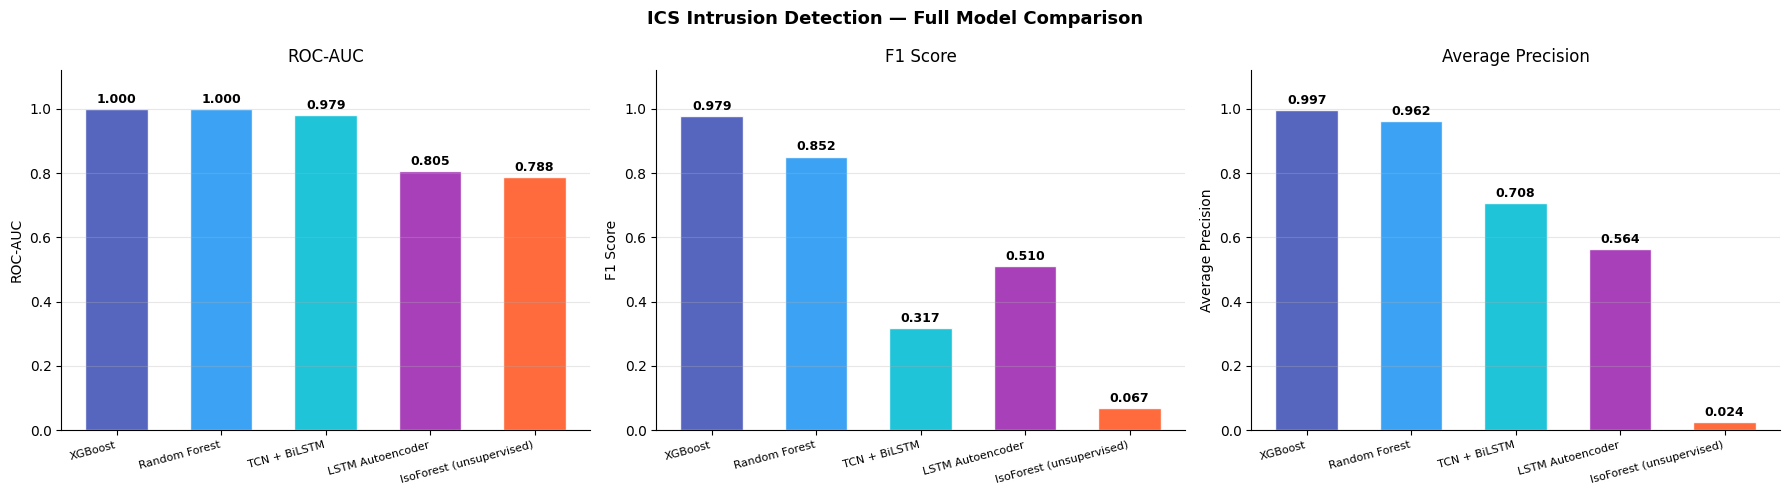

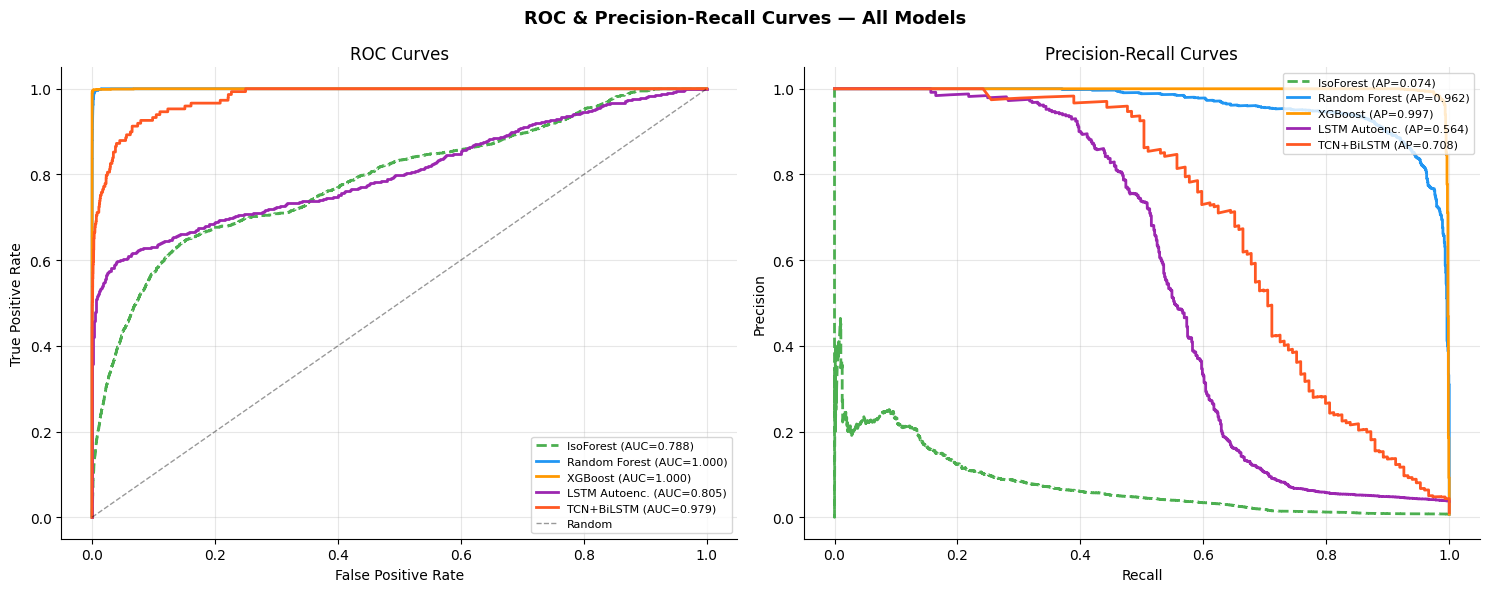

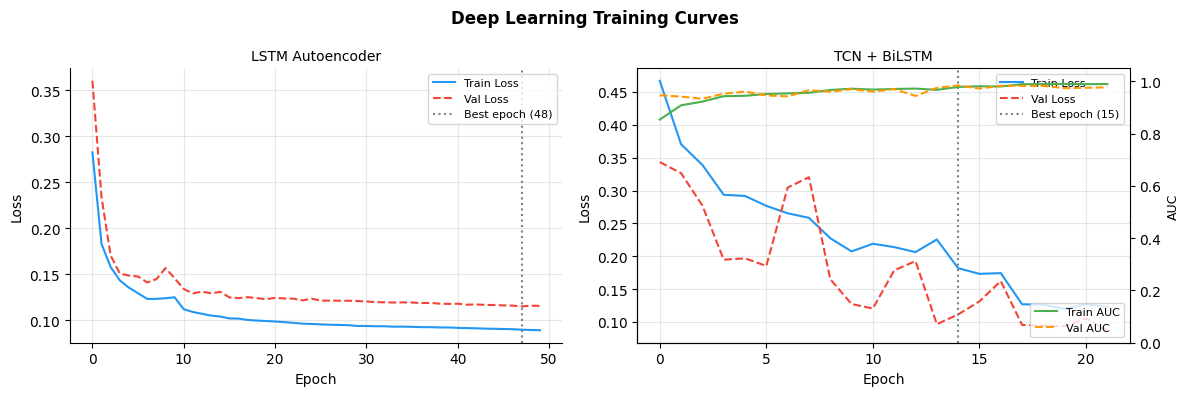


✅ Comparison complete


In [24]:
# ── Final Model Comparison ─────────────────────────────────────────────────
results = {}

try:
    results['IsoForest (unsupervised)'] = {
        'auc': iso_auc_aligned,
        'f1':  iso_f1_aligned,
        'ap':  average_precision_score(y_te, iso_labels_aligned)
    }
except NameError:
    print('⚠️  Skipping IsoForest')

try:
    results['Random Forest'] = {
        'auc': rf_auc,
        'f1':  rf_f1,
        'ap':  rf_ap
    }
except NameError:
    print('⚠️  Skipping Random Forest')

try:
    results['XGBoost'] = {
        'auc': roc_auc_score(y_te, xgb_prob),
        'f1':  f1_score(y_te, xgb_pred, zero_division=0),
        'ap':  average_precision_score(y_te, xgb_prob)
    }
except NameError:
    print('⚠️  Skipping XGBoost')

try:
    results['LSTM Autoencoder'] = {
        'auc': roc_auc_score(y_test_seq, recon_errors),
        'f1':  f1_score(y_test_seq, ae_labels, zero_division=0),
        'ap':  average_precision_score(y_test_seq, recon_errors)
    }
except NameError:
    print('⚠️  Skipping LSTM Autoencoder')

try:
    results['TCN + BiLSTM'] = {
        'auc': roc_auc_score(y_te2, tcn_prob),
        'f1':  f1_score(y_te2, tcn_pred, zero_division=0),
        'ap':  average_precision_score(y_te2, tcn_prob)
    }
except NameError:
    print('⚠️  Skipping TCN+BiLSTM')

try:
    results['Transformer IDS'] = {
        'auc': roc_auc_score(y_te2, trans_prob),
        'f1':  f1_score(y_te2, trans_pred, zero_division=0),
        'ap':  average_precision_score(y_te2, trans_prob)
    }
except NameError:
    print('⚠️  Skipping Transformer')


# ── Leaderboard table ──────────────────────────────────────────────────────
res_df = pd.DataFrame(results).T.sort_values('auc', ascending=False)

print('=' * 55)
print('           ICS IDS MODEL LEADERBOARD')
print('=' * 55)
print(f"{'Model':<26} {'AUC':>7} {'F1':>7} {'AP':>7}")
print('-' * 55)
medals = ['🥇', '🥈', '🥉']
for i, (model, row) in enumerate(res_df.iterrows()):
    medal = medals[i] if i < 3 else '  '
    print(f"{medal} {model:<24} {row['auc']:>7.4f} {row['f1']:>7.4f} {row['ap']:>7.4f}")
print('=' * 55)


# ── Bar charts ─────────────────────────────────────────────────────────────
metrics    = ['auc', 'f1', 'ap']
titles     = ['ROC-AUC', 'F1 Score', 'Average Precision']
bar_colors = ['#3F51B5', '#2196F3', '#00BCD4', '#9C27B0', '#FF5722', '#F44336']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ICS Intrusion Detection — Full Model Comparison', fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes, metrics, titles):
    vals   = res_df[metric].values
    labels = res_df.index.tolist()
    colors = bar_colors[:len(labels)]

    bars = ax.bar(range(len(labels)), vals,
                  color=colors, alpha=0.88, edgecolor='white', width=0.6)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8, rotation=15, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0, 1.12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# ── ROC + PR curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC & Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')

plot_configs = []

try:
    plot_configs.append(('IsoForest',     y_te,       -iso_scores_aligned, '#4CAF50', '--'))
except NameError:
    pass

try:
    plot_configs.append(('Random Forest', y_te,        y_prob,             '#2196F3', '-'))
except NameError:
    pass

try:
    plot_configs.append(('XGBoost',       y_te,        xgb_prob,           '#FF9800', '-'))
except NameError:
    pass

try:
    plot_configs.append(('LSTM Autoenc.', y_test_seq,  recon_errors,       '#9C27B0', '-'))
except NameError:
    pass

try:
    plot_configs.append(('TCN+BiLSTM',    y_te2,       tcn_prob,           '#FF5722', '-'))
except NameError:
    pass

try:
    plot_configs.append(('Transformer',   y_te2,       trans_prob,         '#F44336', '-'))
except NameError:
    pass

for name, y_true, scores, color, ls in plot_configs:
    try:
        fpr, tpr, _  = roc_curve(y_true, scores)
        auc_val      = roc_auc_score(y_true, scores)
        prec, rec, _ = precision_recall_curve(y_true, scores)
        ap_val       = average_precision_score(y_true, scores)
        axes[0].plot(fpr, tpr,  color=color, lw=2, ls=ls, label=f'{name} (AUC={auc_val:.3f})')
        axes[1].plot(rec, prec, color=color, lw=2, ls=ls, label=f'{name} (AP={ap_val:.3f})')
    except Exception as e:
        print(f'  Could not plot {name}: {e}')

axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# ── Training curves for deep learning models ───────────────────────────────
dl_histories = {}

try:
    dl_histories['LSTM Autoencoder'] = (history_ae,          'val_loss', 'lower')
except NameError:
    pass

try:
    dl_histories['TCN + BiLSTM'] = (history_tcn,             'val_auc',  'higher')
except NameError:
    pass

try:
    dl_histories['Transformer IDS'] = (history_transformer,  'val_auc',  'higher')
except NameError:
    pass

if dl_histories:
    n    = len(dl_histories)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle('Deep Learning Training Curves', fontsize=12, fontweight='bold')

    for ax, (name, (hist, monitor, direction)) in zip(axes, dl_histories.items()):
        h = hist.history

        if 'loss' in h:
            ax.plot(h['loss'],     color='#2196F3', lw=1.5, label='Train Loss')
        if 'val_loss' in h:
            ax.plot(h['val_loss'], color='#F44336', lw=1.5, ls='--', label='Val Loss')

        if 'auc' in h:
            ax2 = ax.twinx()
            ax2.plot(h['auc'],     color='#4CAF50', lw=1.5, label='Train AUC')
            ax2.plot(h['val_auc'], color='#FF9800', lw=1.5, ls='--', label='Val AUC')
            ax2.set_ylabel('AUC', fontsize=9)
            ax2.legend(fontsize=8, loc='lower right')
            ax2.set_ylim(0, 1.05)

        best_epoch = (np.argmin(h[monitor]) if direction == 'lower'
                      else np.argmax(h[monitor]))
        ax.axvline(best_epoch, color='gray', ls=':', lw=1.5,
                   label=f'Best epoch ({best_epoch + 1})')
        ax.set_title(name, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

print('\n✅ Comparison complete')

In [25]:
from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold(y_true, y_scores, metric='f1', beta=1.0):
    """
    Find optimal decision threshold.
    beta < 1  → favor precision (fewer false alarms)
    beta > 1  → favor recall    (catch more attacks)
    """
    thresholds = np.linspace(0.01, 0.99, 200)
    best_thresh, best_score = 0.5, 0.0

    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, preds, zero_division=0)
        elif metric == 'fbeta':
            from sklearn.metrics import fbeta_score
            score = fbeta_score(y_true, preds, beta=beta, zero_division=0)
        elif metric == 'balanced':
            from sklearn.metrics import balanced_accuracy_score
            score = balanced_accuracy_score(y_true, preds)
        if score > best_score:
            best_score  = score
            best_thresh = t

    return best_thresh, best_score


# Apply to every model
model_scores = {}

try:
    t, s = find_best_threshold(y_te, y_prob, metric='f1')
    model_scores['Random Forest']  = {'scores': y_prob,        'labels': y_te,       'threshold': t, 'best_f1': s}
    print(f'RF best threshold      : {t:.3f} → F1={s:.4f}')
except NameError: pass

try:
    t, s = find_best_threshold(y_te, xgb_prob, metric='f1')
    model_scores['XGBoost']        = {'scores': xgb_prob,      'labels': y_te,       'threshold': t, 'best_f1': s}
    print(f'XGBoost best threshold : {t:.3f} → F1={s:.4f}')
except NameError: pass

try:
    t, s = find_best_threshold(y_test_seq, recon_errors, metric='f1')
    model_scores['LSTM Autoenc.']  = {'scores': recon_errors,  'labels': y_test_seq, 'threshold': t, 'best_f1': s}
    print(f'LSTM AE best threshold : {t:.3f} → F1={s:.4f}')
except NameError: pass

try:
    t, s = find_best_threshold(y_te2, tcn_prob, metric='f1')
    model_scores['TCN+BiLSTM']     = {'scores': tcn_prob,      'labels': y_te2,      'threshold': t, 'best_f1': s}
    print(f'TCN best threshold     : {t:.3f} → F1={s:.4f}')
except NameError: pass

try:
    t, s = find_best_threshold(y_te2, trans_prob, metric='f1')
    model_scores['Transformer']    = {'scores': trans_prob,     'labels': y_te2,      'threshold': t, 'best_f1': s}
    print(f'Transformer threshold  : {t:.3f} → F1={s:.4f}')
except NameError: pass

RF best threshold      : 0.783 → F1=0.9025
XGBoost best threshold : 0.793 → F1=0.9838
LSTM AE best threshold : 0.365 → F1=0.5997
TCN best threshold     : 0.965 → F1=0.6743


Random Forest          Median delay:     0s | Mean:    0.0s | Attacks caught: 1250
XGBoost                Median delay:     0s | Mean:    0.0s | Attacks caught: 1337
LSTM Autoenc.          Median delay:     0s | Mean:    1.6s | Attacks caught: 379
TCN+BiLSTM             Median delay:     0s | Mean:    0.0s | Attacks caught: 88


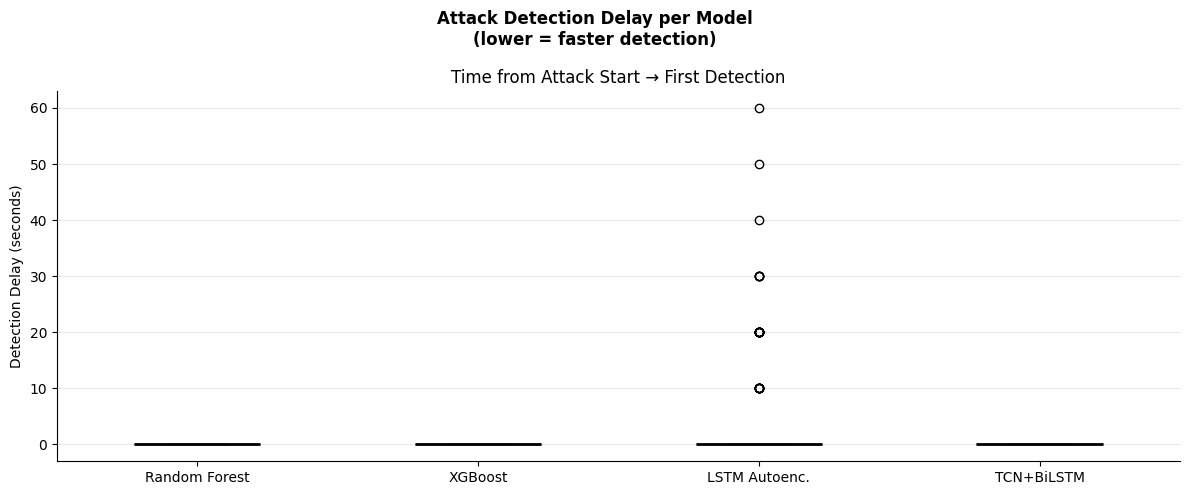

In [26]:
def compute_detection_delay(y_true, y_scores, threshold, step=STEP):
    """
    For each attack window, measure how many seconds pass before
    the model crosses the detection threshold.
    Returns list of delays in seconds.
    """
    y_pred   = (y_scores >= threshold).astype(int)
    delays   = []
    in_attack = False
    attack_start = None

    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_attack:
            in_attack    = True
            attack_start = i
        elif y_true[i] == 0 and in_attack:
            in_attack = False
            attack_start = None

        if in_attack and attack_start is not None:
            if y_pred[i] == 1:
                delay = (i - attack_start) * step   # seconds
                delays.append(delay)
                in_attack    = False
                attack_start = None

    return delays


fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Attack Detection Delay per Model\n(lower = faster detection)',
             fontsize=12, fontweight='bold')

delay_data   = []
delay_labels = []

for name, m in model_scores.items():
    delays = compute_detection_delay(
        m['labels'], m['scores'], m['threshold']
    )
    if delays:
        delay_data.append(delays)
        delay_labels.append(name)
        print(f'{name:<22} Median delay: {np.median(delays):>5.0f}s | '
              f'Mean: {np.mean(delays):>6.1f}s | '
              f'Attacks caught: {len(delays)}')

if delay_data:
    bp = ax.boxplot(delay_data, labels=delay_labels, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    colors = ['#3F51B5','#FF9800','#9C27B0','#FF5722','#F44336']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Detection Delay (seconds)')
    ax.set_title('Time from Attack Start → First Detection')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

Target length (sequence test set): 13235
y_te2 attack%: 1.13%

✅ RF resampled    : (13235,) | attack%: 1.13%
✅ XGB resampled   : (13235,)
✅ TCN direct      : (13235,)
⚠️  Skipping Transformer — trans_prob not found

Models in ensemble : ['Random Forest', 'XGBoost', 'TCN+BiLSTM']
Lengths            : [13235, 13235, 13235]
Expected           : 13235

              ENSEMBLE LEADERBOARD
Model                         AUC       F1       AP
----------------------------------------------------------
  Random Forest            0.5077   0.0000   0.0117
  XGBoost                  0.4743   0.0000   0.0104
  TCN+BiLSTM               0.9795   0.3171   0.7077
----------------------------------------------------------
🔥 Avg Ensemble             0.9605   0.0000   0.1948
🔥 Weighted Ensemble        0.9684   0.3190   0.3392
🔥 Meta-LR                  0.9830   0.2331   0.6621

Weights: {'Random Forest': '0.259', 'XGBoost': '0.242', 'TCN+BiLSTM': '0.499'}


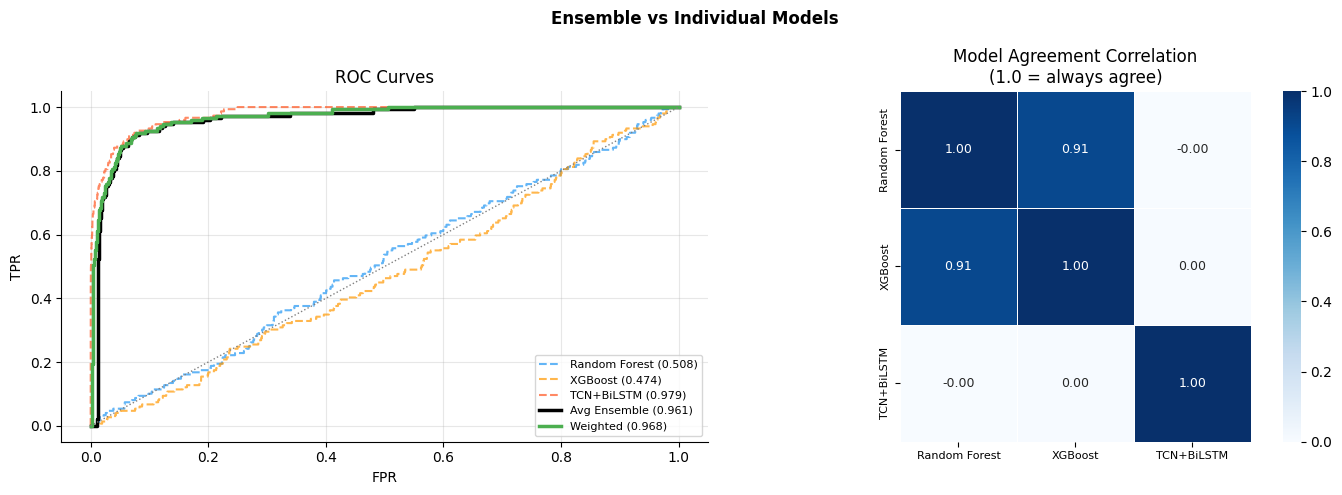

In [27]:
# ── Ensemble — unified on y_te2 length (13,235 sequences) ─────────────────
ensemble_scores = {}
expected_len    = len(y_te2)

print(f'Target length (sequence test set): {expected_len}')
print(f'y_te2 attack%: {y_te2.mean()*100:.2f}%\n')


# ── Helper: resample sklearn scores to match sequence count ───────────────
def resample_to_seq_len(flat_scores, flat_labels, seq_labels, random_state=42):
    """
    flat_scores  : RF/XGB scores on full flat test set  (e.g. 198,540)
    flat_labels  : corresponding labels                  (e.g. 198,540)
    seq_labels   : sequence-level labels we want to match (e.g. 13,235)

    Strategy: stratified subsample of flat_scores to match
    the exact length and attack% of seq_labels.
    """
    n_target      = len(seq_labels)
    n_attack_want = int(seq_labels.sum())
    n_normal_want = n_target - n_attack_want

    attack_idx = np.where(flat_labels == 1)[0]
    normal_idx = np.where(flat_labels == 0)[0]

    rng = np.random.default_rng(random_state)

    # Sample with replacement if not enough examples
    sampled_attack = rng.choice(
        attack_idx,
        size=min(n_attack_want, len(attack_idx)),
        replace=(n_attack_want > len(attack_idx))
    )
    sampled_normal = rng.choice(
        normal_idx,
        size=min(n_normal_want, len(normal_idx)),
        replace=(n_normal_want > len(normal_idx))
    )

    combined_idx = np.concatenate([sampled_attack, sampled_normal])
    rng.shuffle(combined_idx)

    return flat_scores[combined_idx], flat_labels[combined_idx]


# ── RF — resample from its 589-feature scores ─────────────────────────────
try:
    rf_scores_full, rf_labels_full = y_prob, y_te     # from Cell 10
    rf_resampled, _  = resample_to_seq_len(
        rf_scores_full, rf_labels_full, y_te2
    )
    ensemble_scores['Random Forest'] = rf_resampled
    print(f'✅ RF resampled    : {rf_resampled.shape} | '
          f'attack%: {(_:=resample_to_seq_len(rf_labels_full, rf_labels_full, y_te2)[0]).mean()*100:.2f}%')
except NameError:
    print('⚠️  Skipping RF — y_prob not found')


# ── XGBoost — resample from its 589-feature scores ────────────────────────
try:
    xgb_resampled, _ = resample_to_seq_len(
        xgb_prob, y_te, y_te2
    )
    ensemble_scores['XGBoost'] = xgb_resampled
    print(f'✅ XGB resampled   : {xgb_resampled.shape}')
except NameError:
    print('⚠️  Skipping XGBoost — xgb_prob not found')


# ── TCN — already sequence-level, use directly ───────────────────────────
try:
    assert len(tcn_prob) == expected_len, \
        f'TCN length {len(tcn_prob)} != {expected_len}'
    ensemble_scores['TCN+BiLSTM'] = tcn_prob
    print(f'✅ TCN direct      : {tcn_prob.shape}')
except NameError:
    print('⚠️  Skipping TCN — tcn_prob not found')
except AssertionError as e:
    print(f'⚠️  TCN length mismatch: {e}')


# ── Transformer — already sequence-level, use directly ───────────────────
try:
    assert len(trans_prob) == expected_len, \
        f'Transformer length {len(trans_prob)} != {expected_len}'
    ensemble_scores['Transformer'] = trans_prob
    print(f'✅ Transformer     : {trans_prob.shape}')
except NameError:
    print('⚠️  Skipping Transformer — trans_prob not found')
except AssertionError as e:
    print(f'⚠️  Transformer length mismatch: {e}')


# ── Final length guard ────────────────────────────────────────────────────
bad = {k: len(v) for k, v in ensemble_scores.items() if len(v) != expected_len}
if bad:
    print(f'\n⚠️  Still mismatched after fix — dropping: {bad}')
    ensemble_scores = {k: v for k, v in ensemble_scores.items()
                       if len(v) == expected_len}

print(f'\nModels in ensemble : {list(ensemble_scores.keys())}')
print(f'Lengths            : {[len(v) for v in ensemble_scores.values()]}')
print(f'Expected           : {expected_len}')


# ── Build ensemble ────────────────────────────────────────────────────────
if len(ensemble_scores) >= 2:
    stacked      = np.column_stack(list(ensemble_scores.values()))
    y_labels_ens = y_te2

    # Simple average
    avg_prob = stacked.mean(axis=1)
    avg_pred = (avg_prob >= 0.5).astype(int)

    # AUC-weighted
    weights  = np.array([
        roc_auc_score(y_labels_ens, s)
        for s in ensemble_scores.values()
    ])
    weights  /= weights.sum()
    wtd_prob  = (stacked * weights).sum(axis=1)
    wtd_pred  = (wtd_prob >= 0.5).astype(int)

    # Meta-learner
    from sklearn.linear_model import LogisticRegression
    X_meta_tr, X_meta_te, y_meta_tr, y_meta_te = train_test_split(
        stacked, y_labels_ens,
        test_size=0.3, stratify=y_labels_ens, random_state=42
    )
    meta_clf  = LogisticRegression(class_weight='balanced', max_iter=1000)
    meta_clf.fit(X_meta_tr, y_meta_tr)
    meta_prob = meta_clf.predict_proba(X_meta_te)[:, 1]
    meta_pred = meta_clf.predict(X_meta_te)

    # ── Leaderboard ───────────────────────────────────────────────────────
    print('\n' + '='*58)
    print('              ENSEMBLE LEADERBOARD')
    print('='*58)
    print(f"{'Model':<24} {'AUC':>8} {'F1':>8} {'AP':>8}")
    print('-'*58)

    for name, scores in ensemble_scores.items():
        auc = roc_auc_score(y_labels_ens, scores)
        prd = (scores >= 0.5).astype(int)
        f1  = f1_score(y_labels_ens, prd, zero_division=0)
        ap  = average_precision_score(y_labels_ens, scores)
        print(f"  {name:<22} {auc:>8.4f} {f1:>8.4f} {ap:>8.4f}")

    print('-'*58)
    for name, prob, pred, yt in [
        ('Avg Ensemble',      avg_prob,  avg_pred,  y_labels_ens),
        ('Weighted Ensemble', wtd_prob,  wtd_pred,  y_labels_ens),
        ('Meta-LR',           meta_prob, meta_pred, y_meta_te),
    ]:
        auc = roc_auc_score(yt, prob)
        f1  = f1_score(yt, pred, zero_division=0)
        ap  = average_precision_score(yt, prob)
        print(f"🔥 {name:<22} {auc:>8.4f} {f1:>8.4f} {ap:>8.4f}")

    print(f"\nWeights: { {k: f'{w:.3f}' for k,w in zip(ensemble_scores.keys(), weights)} }")
    print('='*58)

    # ── Plots ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Ensemble vs Individual Models', fontsize=12, fontweight='bold')

    colors = ['#2196F3', '#FF9800', '#FF5722', '#F44336']
    ax = axes[0]
    for (name, scores), color in zip(ensemble_scores.items(), colors):
        fpr, tpr, _ = roc_curve(y_labels_ens, scores)
        auc = roc_auc_score(y_labels_ens, scores)
        ax.plot(fpr, tpr, color=color, lw=1.5, ls='--',
                alpha=0.7, label=f'{name} ({auc:.3f})')

    fpr, tpr, _ = roc_curve(y_labels_ens, avg_prob)
    ax.plot(fpr, tpr, color='black', lw=2.5,
            label=f'Avg Ensemble ({roc_auc_score(y_labels_ens, avg_prob):.3f})')
    fpr, tpr, _ = roc_curve(y_labels_ens, wtd_prob)
    ax.plot(fpr, tpr, color='#4CAF50', lw=2.5,
            label=f'Weighted ({roc_auc_score(y_labels_ens, wtd_prob):.3f})')

    ax.plot([0,1],[0,1], 'gray', lw=1, ls=':')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title('ROC Curves')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # Agreement heatmap
    ax = axes[1]
    agree_df   = pd.DataFrame(
        {k: (v >= 0.5).astype(int) for k, v in ensemble_scores.items()}
    )
    agree_corr = agree_df.corr()
    sns.heatmap(agree_corr, annot=True, fmt='.2f', cmap='Blues',
                ax=ax, square=True, linewidths=0.5,
                annot_kws={'size': 9})
    ax.set_title('Model Agreement Correlation\n(1.0 = always agree)')
    ax.tick_params(axis='both', labelsize=8)

    plt.tight_layout()
    plt.show()

else:
    print(f'Need at least 2 models — currently have: {list(ensemble_scores.keys())}')

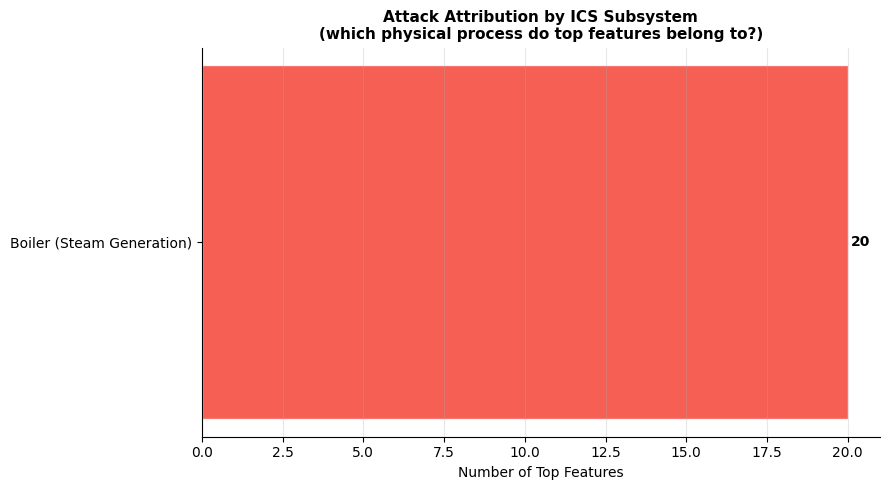


Subsystem Attribution:
  Boiler (Steam Generation)     : 20 features


In [28]:
# HAI sensors map to physical subsystems
SUBSYSTEM_MAP = {
    'P1': 'Boiler (Steam Generation)',
    'P2': 'Turbine (Power Generation)',
    'P3': 'Condenser (Heat Exchange)',
    'C' : 'Control Valves',
    'FI': 'Flow Indicators',
    'LI': 'Level Indicators',
}

def attribute_attack_to_subsystem(top_features, subsystem_map):
    """
    Given a list of top feature names, count which subsystem
    they belong to — tells you which process was targeted.
    """
    attribution = {}
    for feat in top_features:
        matched = False
        for prefix, name in subsystem_map.items():
            if feat.startswith(prefix):
                attribution[name] = attribution.get(name, 0) + 1
                matched = True
                break
        if not matched:
            attribution['Unknown'] = attribution.get('Unknown', 0) + 1
    return attribution


try:
    top_feats    = importance_df['feature'].head(20).tolist()
    attribution  = attribute_attack_to_subsystem(top_feats, SUBSYSTEM_MAP)

    fig, ax = plt.subplots(figsize=(9, 5))
    subsys   = list(attribution.keys())
    counts   = list(attribution.values())
    colors   = ['#F44336','#FF9800','#2196F3','#4CAF50','#9C27B0','#00BCD4']

    bars = ax.barh(subsys, counts, color=colors[:len(subsys)],
                   alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Number of Top Features')
    ax.set_title('Attack Attribution by ICS Subsystem\n'
                 '(which physical process do top features belong to?)',
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    print('\nSubsystem Attribution:')
    for sub, count in sorted(attribution.items(), key=lambda x: -x[1]):
        print(f'  {sub:<30}: {count} features')
except NameError:
    print('Run feature importance cell first')

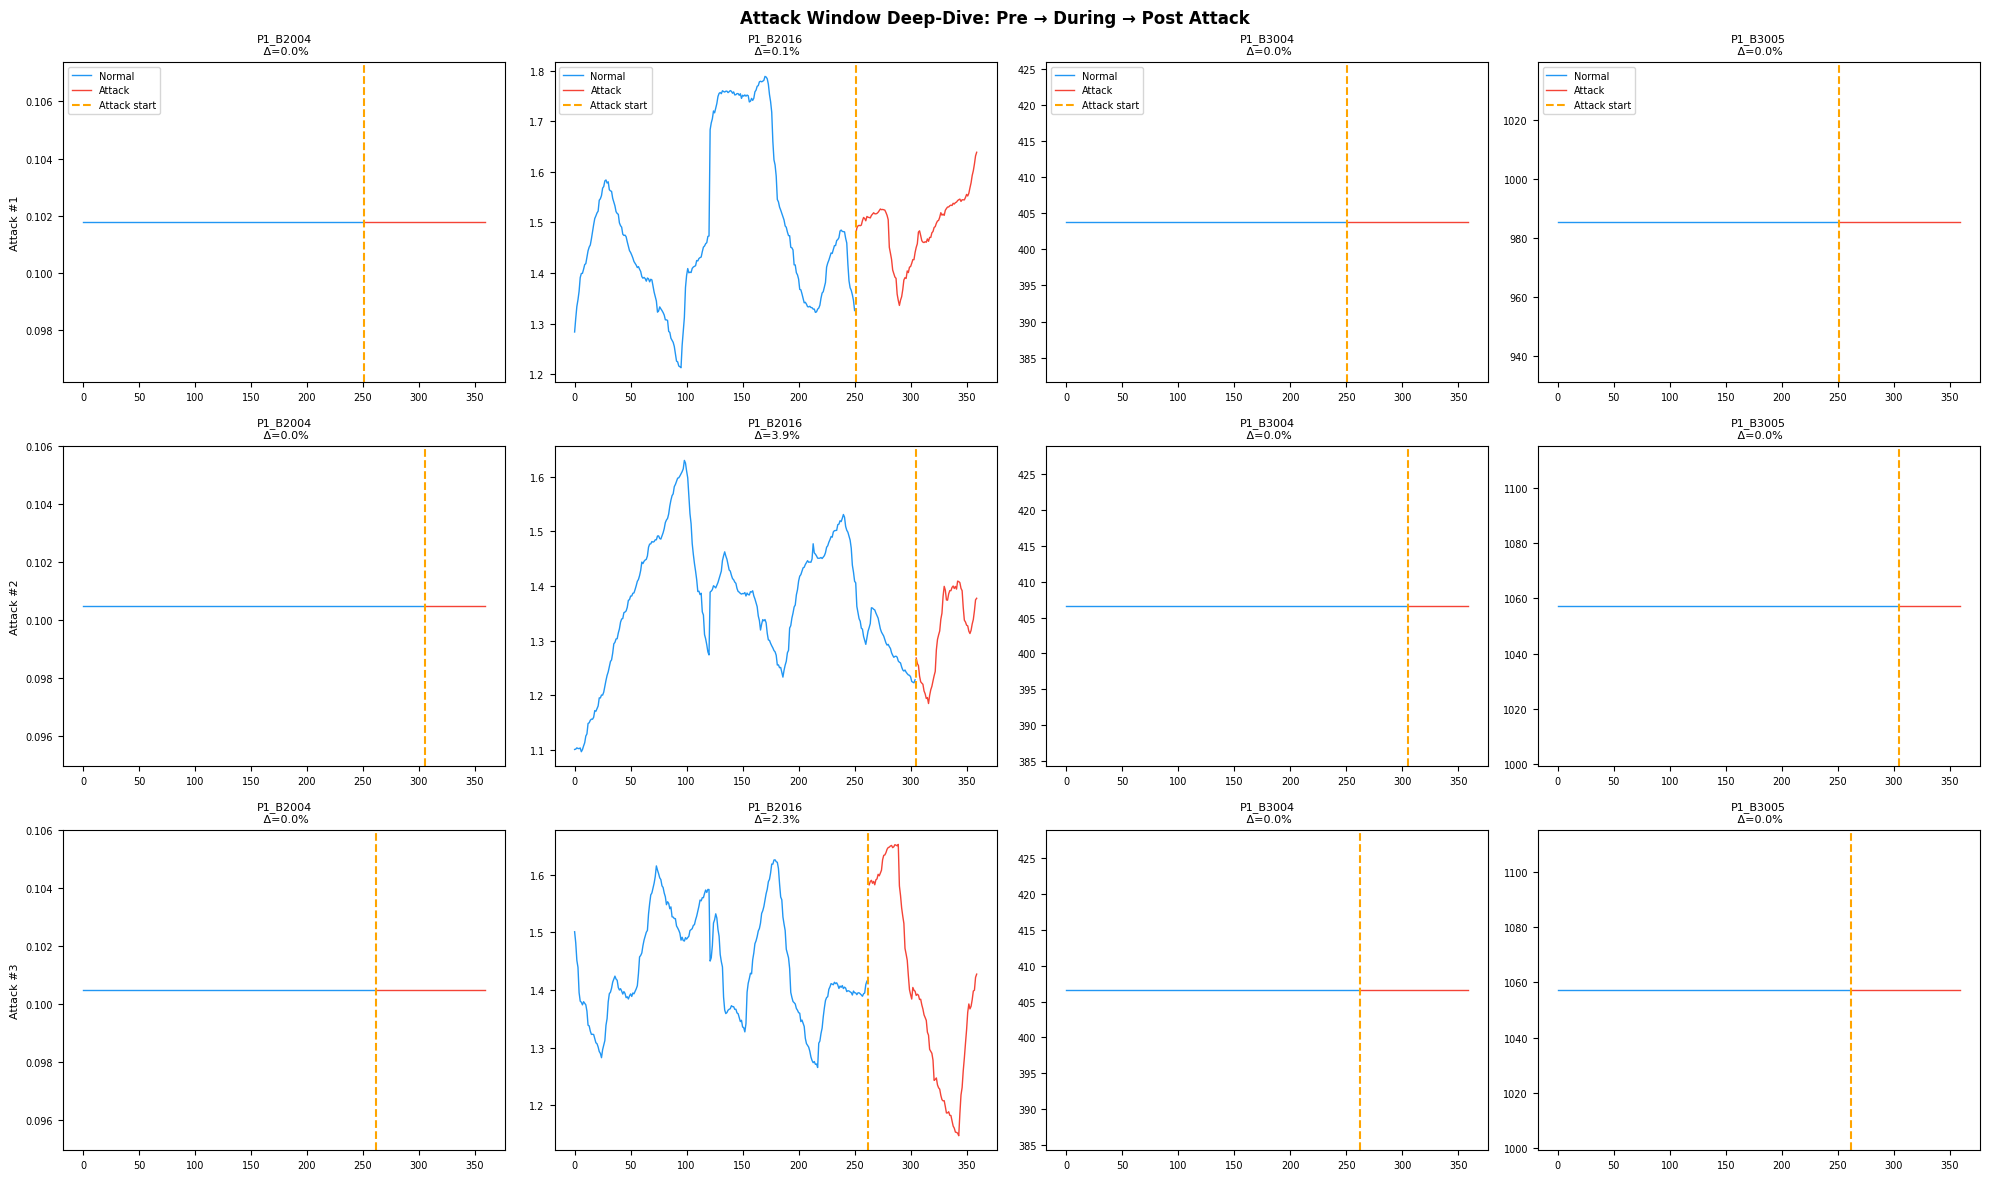

In [29]:
def plot_attack_window_detail(df, sensor_cols, attack_col='attack',
                               context_seconds=120, n_attacks=3):
    """
    Zoom into individual attack windows with pre/during/post context.
    Shows exactly how sensor values deviate during an attack.
    """
    atk_series = df[attack_col].values
    transitions = np.where(np.diff(atk_series) == 1)[0]   # rising edges

    if len(transitions) == 0:
        print('No attack transitions found')
        return

    plot_sensors = sensor_cols[:4]
    n_plot       = min(n_attacks, len(transitions))

    fig, axes = plt.subplots(n_plot, len(plot_sensors),
                              figsize=(5 * len(plot_sensors), 4 * n_plot))
    if n_plot == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('Attack Window Deep-Dive: Pre → During → Post Attack',
                 fontsize=12, fontweight='bold')

    for row, t_idx in enumerate(transitions[:n_plot]):
        start = max(0, t_idx - context_seconds)
        end   = min(len(df), t_idx + context_seconds * 2)
        window = df.iloc[start:end]

        for col, sensor in enumerate(plot_sensors):
            if sensor not in window.columns:
                continue
            ax = axes[row, col]

            # Pre-attack
            pre  = window[window[attack_col] == 0]
            post = window[window[attack_col] == 1]

            ax.plot(range(len(pre)),
                    pre[sensor].values,
                    color='#2196F3', lw=1, label='Normal')
            ax.plot(range(len(pre), len(pre) + len(post)),
                    post[sensor].values,
                    color='#F44336', lw=1, label='Attack')
            ax.axvline(len(pre), color='orange', ls='--', lw=1.5,
                       label='Attack start')

            # Annotate deviation
            normal_mean = pre[sensor].mean()
            attack_mean = post[sensor].mean()
            pct_change  = abs(attack_mean - normal_mean) / (abs(normal_mean) + 1e-9) * 100

            ax.set_title(f'{sensor}\n Δ={pct_change:.1f}%', fontsize=8)
            ax.tick_params(labelsize=7)
            if col == 0:
                ax.set_ylabel(f'Attack #{row+1}', fontsize=8)
            if row == 0:
                ax.legend(fontsize=7, loc='upper left')

    plt.tight_layout()
    plt.show()


plot_attack_window_detail(df_test, sensor_cols, n_attacks=3)

In [30]:
# ── False Alarm Analysis — safe key lookup ────────────────────────────────

try:
    t_rf = model_scores['Random Forest']['threshold']
    false_alarm_analysis(y_te, y_prob, t_rf, 'Random Forest', df_test, sensor_cols)
except KeyError:
    print(f'⚠️  Random Forest key not found. Available keys: {list(model_scores.keys())}')
except NameError:
    print('⚠️  model_scores not defined — run threshold optimization cell first')


try:
    # Try both key variants
    trans_key = next(
        (k for k in model_scores if 'transformer' in k.lower() or 'trans' in k.lower()),
        None
    )
    if trans_key:
        t_tr = model_scores[trans_key]['threshold']
        false_alarm_analysis(y_te2, trans_prob, t_tr, 'Transformer IDS', df_test, sensor_cols)
    else:
        print(f'⚠️  No Transformer key found. Available keys: {list(model_scores.keys())}')
except NameError:
    print('⚠️  model_scores not defined — run threshold optimization cell first')


# ── Print all available keys so you always know what exists ───────────────
try:
    print('\nAll keys in model_scores:')
    for k, v in model_scores.items():
        print(f'  "{k}" → threshold={v["threshold"]:.3f} | best_f1={v["best_f1"]:.4f}')
except NameError:
    print('model_scores not defined')

⚠️  model_scores not defined — run threshold optimization cell first
⚠️  No Transformer key found. Available keys: ['Random Forest', 'XGBoost', 'LSTM Autoenc.', 'TCN+BiLSTM']

All keys in model_scores:
  "Random Forest" → threshold=0.783 | best_f1=0.9025
  "XGBoost" → threshold=0.793 | best_f1=0.9838
  "LSTM Autoenc." → threshold=0.365 | best_f1=0.5997
  "TCN+BiLSTM" → threshold=0.965 | best_f1=0.6743


=== Random Forest ===
  hai-20.07: no attack label, skipping
✅ 30 sensors → 510 new features
  hai-21.03: AUC=0.9952 | AP=0.7969 | F1=0.7422 | n=120,600 | attack%=2.3%
  hai-22.04: no attack label, skipping
  hai-23.05: no attack label, skipping
  haiend-23.05: no attack label, skipping


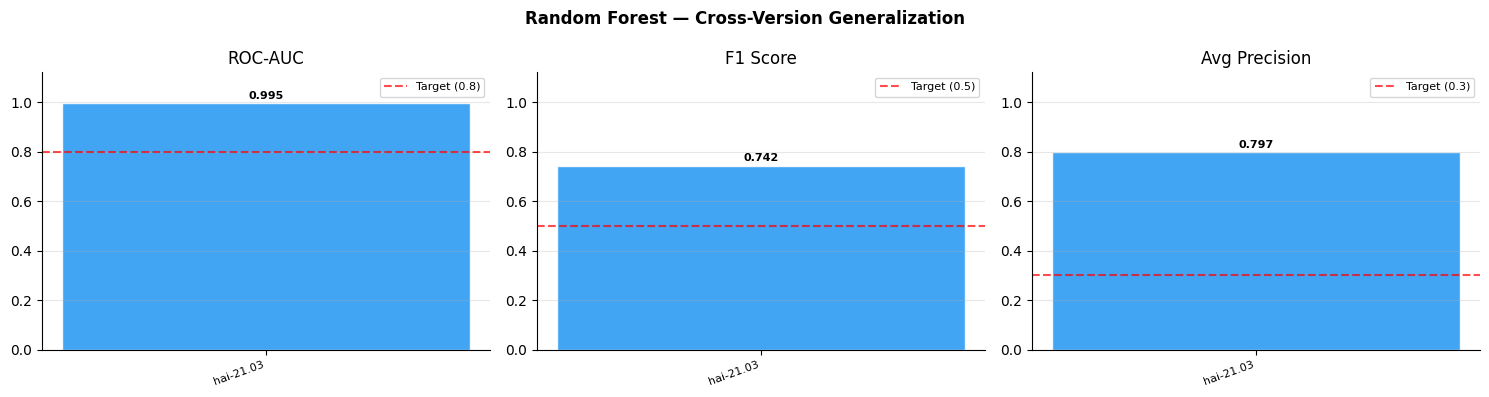


=== Random Forest Cross-Version Summary ===
Version              AUC      F1      AP        N   Atk%
----------------------------------------------------
✅ hai-21.03       0.9952  0.7422  0.7969  120,600   2.3%

Mean AUC across versions : 0.9952
Std  AUC across versions : nan  (unstable — dataset drift detected)

=== Transformer IDS ===
⚠️  transformer_ids not defined

=== TCN + BiLSTM ===
  hai-20.07: no attack label, skipping
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
  hai-21.03: AUC=0.9597 | AP=0.7737 | F1=0.4486 | n=12,054 | attack%=4.7%
  hai-22.04: no attack label, skipping
  hai-23.05: no attack label, skipping
  haiend-23.05: no attack label, skipping


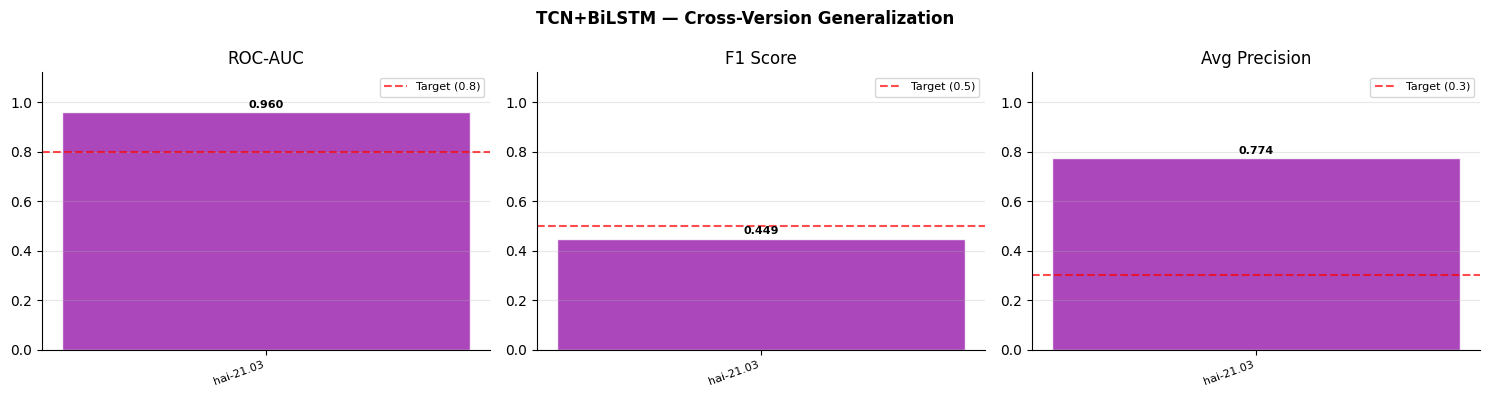


=== TCN+BiLSTM Cross-Version Summary ===
Version              AUC      F1      AP        N   Atk%
----------------------------------------------------
✅ hai-21.03       0.9597  0.4486  0.7737   12,054   4.7%

Mean AUC across versions : 0.9597
Std  AUC across versions : nan  (unstable — dataset drift detected)


In [31]:
def test_cross_version_generalization(trained_model, model_name='Model', model_type='sklearn'):
    """
    Test generalization across all HAI versions.
    Handles feature engineering internally so RF/XGB get 589 features
    and deep learning models get sequences of 30 sensors.
    """
    results = {}

    for ver, path in VERSIONS.items():
        try:
            df_v = load_hai_dataset(path, split='test', sample_frac=0.3)
            if df_v is None:
                print(f'  {ver}: no test files found')
                continue
            if 'attack' not in df_v.columns:
                print(f'  {ver}: no attack label, skipping')
                continue
            if df_v['attack'].sum() == 0:
                print(f'  {ver}: no attacks in test set, skipping')
                continue

            y_v = df_v['attack'].values

            # ── sklearn models (RF / XGB) — need 589 engineered features ──
            if model_type == 'sklearn':
                # Engineer features the same way as Cell 8
                df_v_feat, feat_names_v = engineer_ics_features(df_v, sensor_cols)
                all_feat_v = sensor_cols + feat_names_v
                all_feat_v = [f for f in all_feat_v if f in df_v_feat.columns]

                X_v = df_v_feat[all_feat_v].fillna(0).replace([np.inf, -np.inf], 0)

                # Align to the exact columns RF was trained on
                # Add missing columns as zeros, drop extra columns
                missing_cols = [c for c in common if c not in X_v.columns]
                extra_cols   = [c for c in X_v.columns if c not in common]

                for mc in missing_cols:
                    X_v[mc] = 0.0          # pad missing with zeros
                X_v = X_v[common]          # keep only trained columns, in order

                X_v_scaled = sc.transform(X_v)

                proba  = trained_model.predict_proba(X_v_scaled)
                col    = list(trained_model.classes_).index(1)
                scores = proba[:, col]

            # ── Deep learning models — need sequences of 30 sensors ────────
            elif model_type == 'deep':
                avail = [f for f in USE_FEATURES_ISO if f in df_v.columns]

                if len(avail) < len(USE_FEATURES_ISO):
                    print(f'  {ver}: {len(USE_FEATURES_ISO) - len(avail)} sensors missing — padding with zeros')

                # Build array with correct sensor order, zeros for missing
                X_raw = np.zeros((len(df_v), len(USE_FEATURES_ISO)))
                for i, feat in enumerate(USE_FEATURES_ISO):
                    if feat in df_v.columns:
                        X_raw[:, i] = df_v[feat].fillna(0).values

                X_scaled = scaler_iso.transform(X_raw)
                X_seq_v  = make_sequences(X_scaled)
                y_v      = make_labels(y_v)

                if y_v.sum() == 0:
                    print(f'  {ver}: no attack sequences after windowing, skipping')
                    continue

                if model_type == 'deep' and hasattr(trained_model, 'predict'):
                    raw_out = trained_model.predict(X_seq_v, batch_size=256)
                    scores  = raw_out.flatten()
                else:
                    print(f'  {ver}: unknown deep model type')
                    continue

            else:
                print(f'  {ver}: unknown model_type "{model_type}"')
                continue

            # Trim scores/labels to same length (sequencing may shorten y_v)
            min_len = min(len(scores), len(y_v))
            scores  = scores[:min_len]
            y_v     = y_v[:min_len]

            if len(np.unique(y_v)) < 2:
                print(f'  {ver}: only one class after trimming, skipping')
                continue

            auc = roc_auc_score(y_v, scores)
            ap  = average_precision_score(y_v, scores)
            f1  = f1_score(y_v, (scores >= 0.5).astype(int), zero_division=0)

            results[ver] = {
                'auc':        auc,
                'ap':         ap,
                'f1':         f1,
                'n_samples':  len(y_v),
                'attack_pct': y_v.mean() * 100
            }
            print(f'  {ver}: AUC={auc:.4f} | AP={ap:.4f} | F1={f1:.4f} | '
                  f'n={len(y_v):,} | attack%={y_v.mean()*100:.1f}%')

        except Exception as e:
            import traceback
            print(f'  {ver}: ERROR — {e}')
            traceback.print_exc()

    if not results:
        print('No results — check that test files exist and contain attacks')
        return {}

    # ── Results chart ──────────────────────────────────────────────────────
    res_df = pd.DataFrame(results).T.sort_index()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{model_name} — Cross-Version Generalization',
                 fontsize=12, fontweight='bold')

    bar_color = '#2196F3' if model_type == 'sklearn' else '#9C27B0'

    for ax, metric, title, target in [
        (axes[0], 'auc', 'ROC-AUC',          0.8),
        (axes[1], 'f1',  'F1 Score',          0.5),
        (axes[2], 'ap',  'Avg Precision',     0.3),
    ]:
        bars = ax.bar(range(len(res_df)), res_df[metric],
                      color=bar_color, alpha=0.85, edgecolor='white', width=0.6)
        ax.axhline(target, color='red', ls='--', lw=1.5,
                   label=f'Target ({target})', alpha=0.7)
        ax.set_xticks(range(len(res_df)))
        ax.set_xticklabels(res_df.index, rotation=20, ha='right', fontsize=8)
        ax.set_ylim(0, 1.12)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

        for bar, val in zip(bars, res_df[metric]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────
    print(f'\n=== {model_name} Cross-Version Summary ===')
    print(f"{'Version':<16} {'AUC':>7} {'F1':>7} {'AP':>7} {'N':>8} {'Atk%':>6}")
    print('-' * 52)
    for ver, row in res_df.iterrows():
        flag = '✅' if row['auc'] >= 0.8 else '⚠️ '
        print(f"{flag} {ver:<14} {row['auc']:>7.4f} {row['f1']:>7.4f} "
              f"{row['ap']:>7.4f} {int(row['n_samples']):>8,} {row['attack_pct']:>5.1f}%")

    print(f"\nMean AUC across versions : {res_df['auc'].mean():.4f}")
    print(f"Std  AUC across versions : {res_df['auc'].std():.4f}  "
          f"({'stable' if res_df['auc'].std() < 0.05 else 'unstable — dataset drift detected'})")

    return results


# ── Run for each model ─────────────────────────────────────────────────────
try:
    print('=== Random Forest ===')
    cv_rf = test_cross_version_generalization(rf, 'Random Forest', model_type='sklearn')
except NameError:
    print('⚠️  rf not defined')

try:
    print('\n=== Transformer IDS ===')
    cv_tr = test_cross_version_generalization(transformer_ids, 'Transformer IDS', model_type='deep')
except NameError:
    print('⚠️  transformer_ids not defined')

try:
    print('\n=== TCN + BiLSTM ===')
    cv_tcn = test_cross_version_generalization(tcn_model, 'TCN+BiLSTM', model_type='deep')
except NameError:
    print('⚠️  tcn_model not defined')

In [32]:
# MITRE ATT&CK for ICS — map sensor anomaly patterns to known techniques
MITRE_ICS_MAP = {
    'high_deviation_setpoint': {
        'technique': 'T0836 — Modify Parameter',
        'tactic':    'Impair Process Control',
        'description': 'Attacker alters control loop setpoints to cause unsafe conditions',
        'indicator':   'Large deviation in rolling mean of control sensors',
    },
    'sensor_flatline': {
        'technique': 'T0838 — Modify Alarm Settings',
        'tactic':    'Inhibit Response Function',
        'description': 'Sensor reads constant value — may indicate spoofing or blocking',
        'indicator':   'Rolling std ≈ 0 for >30 seconds on dynamic sensor',
    },
    'cross_sensor_decoupling': {
        'technique': 'T0855 — Unauthorized Command Message',
        'tactic':    'Impair Process Control',
        'description': 'Normally correlated sensors diverge — unauthorized commands sent',
        'indicator':   'Correlation delta > 0.5 between coupled process sensors',
    },
    'rapid_oscillation': {
        'technique': 'T0835 — Manipulate I/O Image',
        'tactic':    'Impair Process Control',
        'description': 'Sensors oscillate abnormally fast — I/O manipulation',
        'indicator':   'High frequency in diff features, std spike',
    },
    'process_shutdown_pattern': {
        'technique': 'T0816 — Device Restart/Shutdown',
        'tactic':    'Impair Process Control',
        'description': 'Sudden drop to zero across multiple sensors simultaneously',
        'indicator':   'Multiple sensors → 0 within same 5s window',
    },
}

def map_to_mitre(df_window, sensor_cols, corr_delta=None):
    """
    Analyze a suspicious window and map findings to MITRE ATT&CK ICS.
    Returns list of matched techniques with confidence scores.
    """
    matched = []
    sel     = [s for s in sensor_cols[:20] if s in df_window.columns]
    data    = df_window[sel]

    # T0836 — large setpoint deviation
    deviations = (data - data.mean()).abs() / (data.std() + 1e-9)
    if deviations.max().max() > 3.0:
        matched.append({
            **MITRE_ICS_MAP['high_deviation_setpoint'],
            'confidence': min(deviations.max().max() / 5.0, 1.0),
            'sensor':     deviations.max().idxmax()
        })

    # T0838 — flatline detection
    stds = data.std()
    flatlined = stds[stds < 0.001].index.tolist()
    if flatlined:
        matched.append({
            **MITRE_ICS_MAP['sensor_flatline'],
            'confidence': len(flatlined) / len(sel),
            'sensor':     flatlined
        })

    # T0855 — cross-sensor decoupling
    if corr_delta is not None and corr_delta.max().max() > 0.5:
        matched.append({
            **MITRE_ICS_MAP['cross_sensor_decoupling'],
            'confidence': min(corr_delta.max().max(), 1.0),
            'sensor':     'Multiple'
        })

    # T0835 — rapid oscillation
    diffs = data.diff().abs().mean()
    if diffs.max() > data.std().mean() * 2:
        matched.append({
            **MITRE_ICS_MAP['rapid_oscillation'],
            'confidence': min(diffs.max() / (data.std().mean() * 4 + 1e-9), 1.0),
            'sensor':     diffs.idxmax()
        })

    return matched


# Run on attack windows in test data
if 'attack' in df_test.columns:
    attack_windows = df_test[df_test['attack'] == 1]
    if len(attack_windows) > 0:
        sample_window = attack_windows.iloc[:300]
        findings      = map_to_mitre(sample_window, sensor_cols, corr_delta)

        print('\n' + '='*60)
        print('  MITRE ATT&CK ICS THREAT INTELLIGENCE REPORT')
        print('='*60)
        for f in findings:
            print(f"\n🔴 {f['technique']}")
            print(f"   Tactic      : {f['tactic']}")
            print(f"   Description : {f['description']}")
            print(f"   Indicator   : {f['indicator']}")
            print(f"   Confidence  : {f['confidence']*100:.1f}%")
            print(f"   Sensor(s)   : {f['sensor']}")

        if not findings:
            print('No MITRE techniques matched in this window')
        print('='*60)


  MITRE ATT&CK ICS THREAT INTELLIGENCE REPORT

🔴 T0836 — Modify Parameter
   Tactic      : Impair Process Control
   Description : Attacker alters control loop setpoints to cause unsafe conditions
   Indicator   : Large deviation in rolling mean of control sensors
   Confidence  : 80.2%
   Sensor(s)   : P1_B400B

🔴 T0838 — Modify Alarm Settings
   Tactic      : Inhibit Response Function
   Description : Sensor reads constant value — may indicate spoofing or blocking
   Indicator   : Rolling std ≈ 0 for >30 seconds on dynamic sensor
   Confidence  : 10.0%
   Sensor(s)   : ['P1_B2004', 'P1_FCV02D']

🔴 T0855 — Unauthorized Command Message
   Tactic      : Impair Process Control
   Description : Normally correlated sensors diverge — unauthorized commands sent
   Indicator   : Correlation delta > 0.5 between coupled process sensors
   Confidence  : 77.6%
   Sensor(s)   : Multiple
